# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

**Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Imagine poder prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

**Objetivo**

Queremos desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, vamos usar uma base de dados que contém informações detalhadas sobre os clientes, incluindo:

Dados demográficos (idade, renda, etc.)

Informações sobre compras anteriores



# Base de dados:

Year_Birth: Ano de nascimento do cliente.

Education: Nível de escolaridade do cliente.

Marital_Status: Estado civil do cliente.

Income: Renda anual da família do cliente.

Kidhome: Número de crianças na casa do cliente.

Recency: Número de dias desde a última compra do cliente.

Complain: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.

MntWines: Valor gasto em vinhos nos últimos 2 anos.

MntFruits: Valor gasto em frutas nos últimos 2 anos.

MntMeatProducts: Valor gasto em carnes nos últimos 2 anos.

MntFishProducts: Valor gasto em peixes nos últimos 2 anos.

MntSweetProducts: Valor gasto em doces nos últimos 2 anos.

MntGoldProds: Valor gasto em produtos de ouro nos últimos 2 anos.

NumDealsPurchases: Número de compras feitas com desconto

NumStorePurchases: Número de compras feitas diretamente nas lojas.

NumWebVisitsMonth: Número de visitas ao site da empresa no último mês.






**WebPurchases: Número de compras feitas pelo site da empresa.**

# ETAPA 1:

**Preparação dos Dados**

In [38]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   -- ------------------------------------- 6.6/101.7 MB 42.3 MB/s eta 0:00:03
   ------ --------------------------------- 15.7/101.7 MB 40.5 MB/s eta 0:00:03
   --------- ------------------------------ 25.2/101.7 MB 42.9 MB/s eta 0:00:02
   ------------- -------------------------- 34.1/101.7 MB 43.2 MB/s eta 0:00:02
   ----------------- ---------------------- 45.1/101.7 MB 44.7 MB/s eta 0:00:02
   --------------------- ------------------ 55.8/101.7 MB 45.6 MB/s eta 0:00:02
   ------------------------- -------------- 65.0/101.7 MB 45.6 MB/s eta 0:00:01
   ----------------------------- ---------- 74.4/101.7 MB 45.7 MB/s eta 0:00:01
   -------------------------------- ------- 83.4/101.7 MB 45.3 MB/s eta 0:00:01
   ------------------------------------- -- 94.4/101.7 MB 46.0 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 46.2 MB/s eta 0:00:01
   ---------------------------------------- 101.7/

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from scipy import stats
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.exceptions import NotFittedError
from matplotlib.ticker import FuncFormatter
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('marketing_campaign.csv', delimiter=';')

df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1


**Preparação dos Dados**

**Exploração e Limpeza:** Analisar e limpar os dados para garantir que estejam prontos para a modelagem.

In [11]:
if 'df' not in globals():
    raise NameError("DataFrame 'df' não encontrado. Confirme que você rodou: df = pd.read_csv('marketing_campaign.csv', delimiter=';')")

# validar importação
print("Preview (head) do df original:")
display(df.head())

# checar colunas esperadas
expected_cols = {'Year_Birth','Income','Education'}
missing_cols = expected_cols.difference(set(df.columns))
if missing_cols:
    raise KeyError(f"As colunas esperadas estão ausentes: {missing_cols}. Verifique os nomes/encoding do CSV.")

# 
df_clean = df.copy()

#  Exploração rápida 
print("SHAPE inicial:", df_clean.shape)
print("\nTipos de dados:")
display(df_clean.dtypes)
print("\nResumo numérico (describe):")
display(df_clean.describe(include=[np.number]).T)
print("\nContagem de missing por coluna:")
display(df_clean.isna().sum().sort_values(ascending=False))

#  Duplicatas: inspecionar e remover duplicatas exatas
n_dup_exact = int(df_clean.duplicated().sum())
print(f"\nDuplicatas exatas detectadas: {n_dup_exact}")
if n_dup_exact > 0:
    print("Exemplo de duplicatas (mostrando primeiras 20 linhas duplicadas):")
    display(df_clean[df_clean.duplicated(keep=False)].sort_values(list(df_clean.columns)).head(20))
    # remover duplicatas exatas
    before = df_clean.shape[0]
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    after = df_clean.shape[0]
    print(f"Removidas {before - after} duplicatas exatas. Novo shape: {df_clean.shape}")
else:
    print("Nenhuma duplicata exata encontrada — nada removido.")

#  Year_Birth: identificar valores absurdos e tratar 
lower_year, upper_year = 1920, 2005  # intervalo plausível
col_year = 'Year_Birth'
# criar flag (1 = fora do intervalo)
mask_out_of_range = ~df_clean[col_year].between(lower_year, upper_year)
df_clean.loc[:, 'Year_Birth_out_of_range'] = mask_out_of_range.astype(int)
n_out_of_range = int(df_clean['Year_Birth_out_of_range'].sum())
print(f"\n{col_year} fora do intervalo [{lower_year}, {upper_year}]: {n_out_of_range}")

if n_out_of_range > 0:
    print("Exemplos de linhas com Year_Birth fora do intervalo:")
    display(df_clean.loc[mask_out_of_range].head(20))

# Substituir valores fora do intervalo por NaN
df_clean.loc[mask_out_of_range, col_year] = np.nan

# Imputar Year_Birth: mediana por Education -> fallback mediana global
if 'Education' in df_clean.columns:
    median_by_edu = df_clean.groupby('Education')[col_year].transform('median')
else:
    median_by_edu = pd.Series(np.nan, index=df_clean.index)

median_global = df_clean[col_year].median()
df_clean.loc[:, col_year] = df_clean[col_year].fillna(median_by_edu)
df_clean.loc[:, col_year] = df_clean[col_year].fillna(median_global)

# Criar Age a partir do ano atual (auditável)
current_year = pd.Timestamp.today().year
df_clean.loc[:, 'Age'] = current_year - df_clean[col_year]

# Checar idades implausíveis após imputação
idade_implausivel_mask = (df_clean['Age'] < 16) | (df_clean['Age'] > 100)
n_implausive_ages = int(idade_implausivel_mask.sum())
print(f"Idades implausíveis (<16 ou >100) após imputação: {n_implausive_ages}")
if n_implausive_ages > 0:
    display(df_clean.loc[idade_implausivel_mask].head(20))

# Income: revisar outliers e aplicar cap (winsorize)
col_income = 'Income'

# preservar cópia original
df_clean.loc[:, 'Income_original'] = df_clean[col_income].copy()

# calcular p01 e p99 ignorando NA
p01 = float(df_clean[col_income].dropna().quantile(0.01))
p99 = float(df_clean[col_income].dropna().quantile(0.99))
print(f"\nIncome p01 = {p01:.2f}, p99 = {p99:.2f}")

# flag de outlier
mask_income_outlier = ~df_clean[col_income].between(p01, p99)
df_clean.loc[:, 'Income_outlier_flag'] = mask_income_outlier.astype(int)
n_income_outliers = int(mask_income_outlier.sum())
print(f"Linhas com Income fora de [p01, p99]: {n_income_outliers}")

# mostrar top incomes para inspeção (antes do cap)
print("Top incomes (antes do cap) — colunas: Income_original, Income, Education, Marital_Status")
display(df_clean.sort_values(col_income, ascending=False)[['Income_original', col_income, 'Education', 'Marital_Status']].head(20))

# aplicar cap (winsorize) usando clip (mantém NaN se existirem)
df_clean.loc[:, col_income] = df_clean[col_income].clip(lower=p01, upper=p99)

# criar transformação log1p 
df_clean.loc[:, 'Income_log'] = np.where(df_clean[col_income].notna() & (df_clean[col_income] >= 0),
                                         np.log1p(df_clean[col_income]), np.nan)

#  Checagens finais 
print("\nSHAPE final:", df_clean.shape)
print("\nResumo (numéricas):")
display(df_clean.select_dtypes(include=[np.number]).describe().T)

print("\nExemplos de valores únicos (categóricas):")
for c in df_clean.select_dtypes(include=['object','category']).columns:
    sample_vals = df_clean[c].dropna().unique()[:5].tolist()
    print(f"- {c}: {df_clean[c].nunique()} valores (ex.: {sample_vals})")

print("\nMissing por coluna (somente > 0):")
missing_summary = df_clean.isna().sum()
display(missing_summary[missing_summary > 0])



Preview (head) do df original:


,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1


SHAPE inicial: (2240, 16)

Tipos de dados:


Year_Birth             int64
Education             object
Marital_Status        object
Income               float64
Kidhome                int64
Recency                int64
MntWines               int64
MntFruits              int64
MntMeatProducts        int64
MntFishProducts        int64
MntSweetProducts       int64
MntGoldProds           int64
NumStorePurchases      int64
NumWebVisitsMonth      int64
Complain               int64
WebPurchases           int64
dtype: object


Resumo numérico (describe):


...

,Income_original,Income,Education,Marital_Status
2034,666666.0,666666.0,Graduation,Together
602,162397.0,162397.0,PhD,Together
667,160803.0,160803.0,PhD,Married
1240,157733.0,157733.0,Master,Together
163,157243.0,157243.0,PhD,Married
1536,157146.0,157146.0,Graduation,Together
1947,156924.0,156924.0,PhD,Married
638,153924.0,153924.0,Graduation,Divorced
1745,113734.0,113734.0,PhD,Single
629,105471.0,105471.0,Graduation,Together



SHAPE final: (2039, 21)

Resumo (numéricas):


,count,mean,std,min,25%,50%,75%,max
Year_Birth,2039.0,1968.878372,11.666023,1940.000000,1959.000000,1970.000000,1977.00000,1996.000000
Income,2015.0,51840.369826,20748.892612,7500.000000,35533.500000,51537.000000,68641.00000,94618.200000
Kidhome,2039.0,0.444826,0.537843,0.000000,0.000000,0.000000,1.00000,2.000000
Recency,2039.0,49.096616,28.974507,0.000000,24.000000,49.000000,74.00000,99.000000
MntWines,2039.0,303.332026,335.823263,0.000000,23.000000,174.000000,503.50000,1493.000000
MntFruits,2039.0,26.351153,39.824028,0.000000,2.000000,8.000000,33.00000,199.000000
MntMeatProducts,2039.0,167.755272,227.930430,0.000000,16.000000,67.000000,230.00000,1725.000000
MntFishProducts,2039.0,37.456596,54.704882,0.000000,3.000000,12.000000,50.00000,259.000000
MntSweetProducts,2039.0,27.215792,41.701678,0.000000,1.000000,8.000000,34.00000,263.000000
MntGoldProds,2039.0,43.760177,52.024687,0.000000,9.000000,24.000000,56.00000,362.000000



Exemplos de valores únicos (categóricas):
- Education: 5 valores (ex.: ['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'])
- Marital_Status: 8 valores (ex.: ['Single', 'Together', 'Married', 'Divorced', 'Widow'])

Missing por coluna (somente > 0):


Income             24
Income_original    24
Income_log         24
dtype: int64

**Preparação dos Dados**


**Análise:** Construa uma storytelling com gráficos, analisando e retirando insights das informações.

Pré-processamento complementar concluído.
Clientes Web : 1128
Clientes Loja: 1112

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 CAPÍTULO 1 — VISÃO GERAL: QUEM COMPRA ONDE?
 Qual canal concentra mais clientes? Há perfis distintos?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



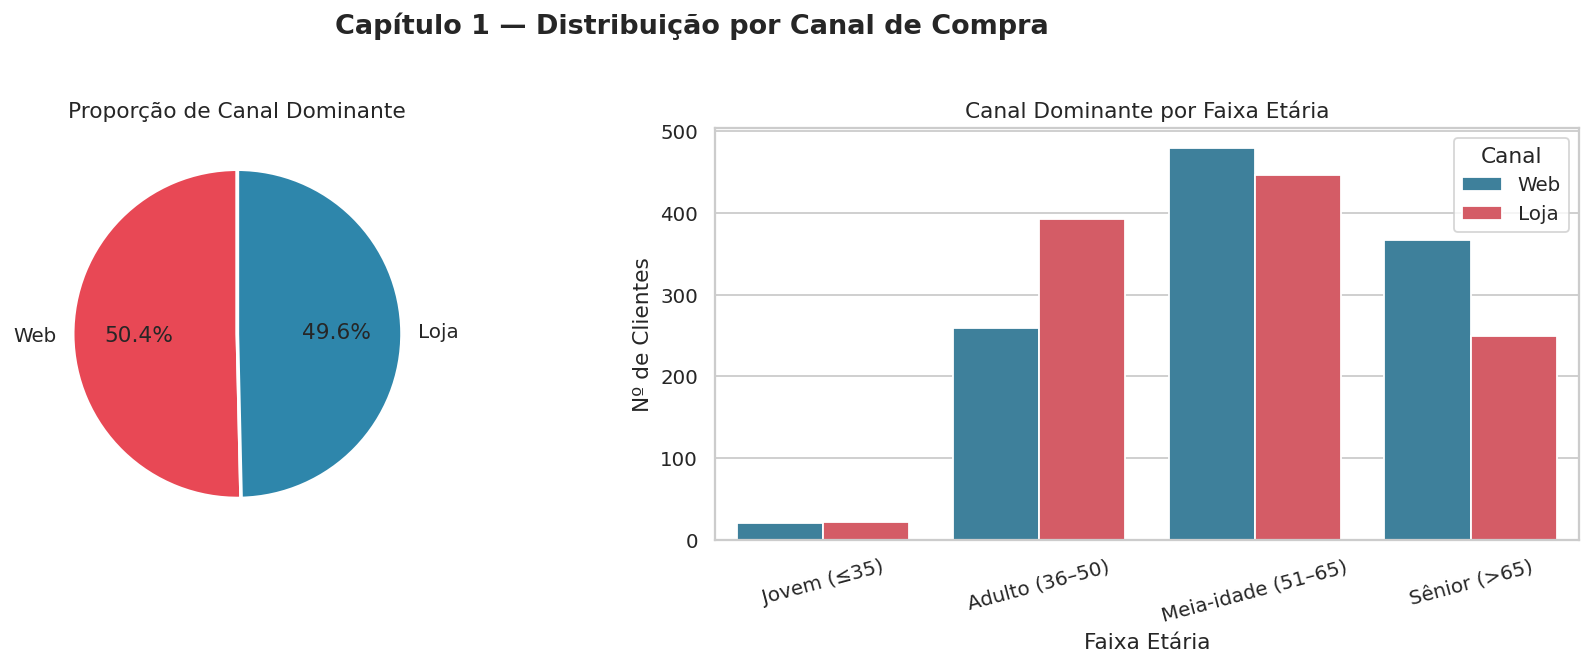


📌 INSIGHT 1:
   Aproximadamente metade dos clientes realizou ao menos uma compra online (Web).
   Clientes mais jovens apresentam maior adesão ao canal web, enquanto o público
   sênior ainda favorece a loja física — um padrão clássico de comportamento digital.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 CAPÍTULO 2 — COMPORTAMENTO DE GASTO POR CANAL
 Clientes web gastam mais? Em quais categorias?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



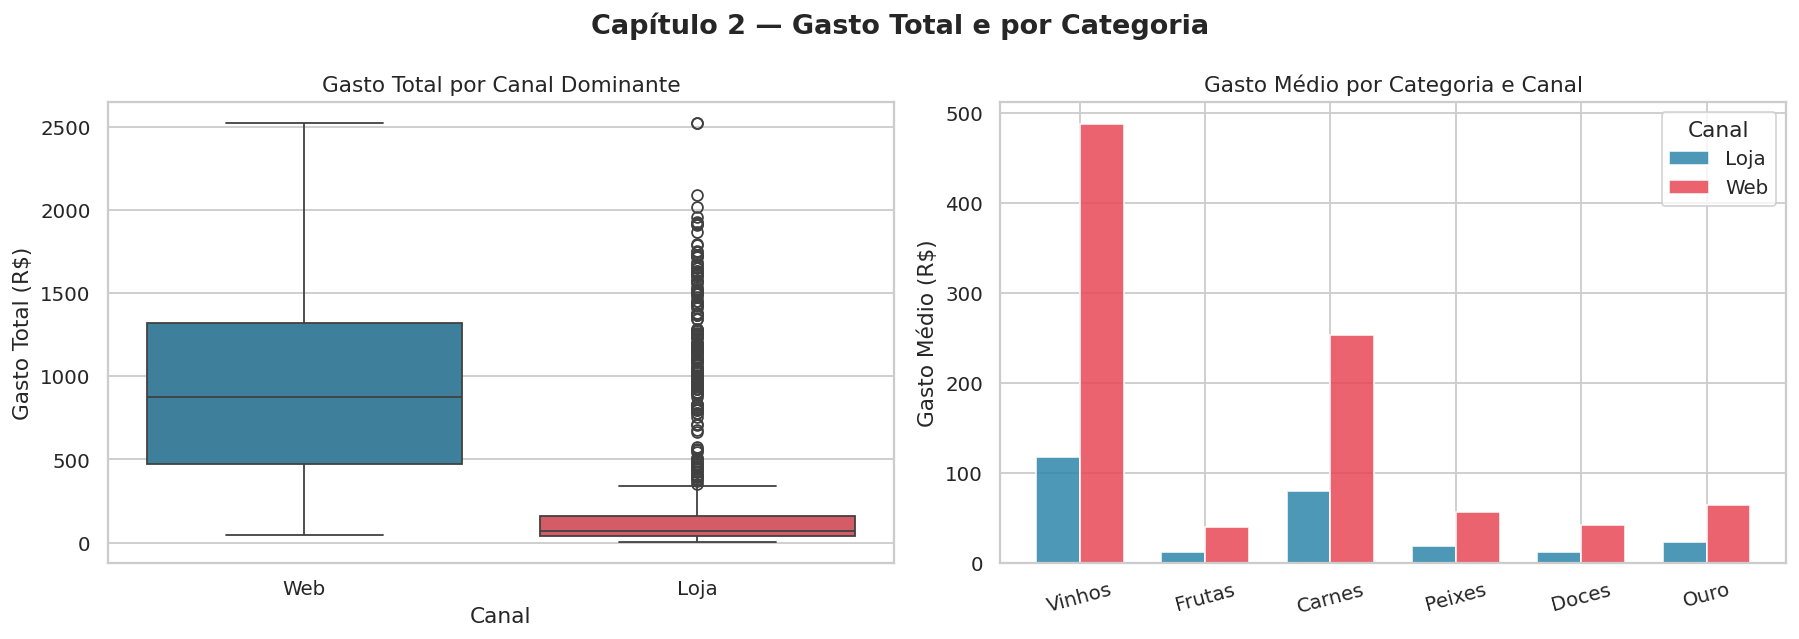


📌 INSIGHT 2:
   Clientes web tendem a ter maior gasto total mediano em comparação aos
   exclusivos da loja. Vinhos e Carnes lideram o gasto em ambos os canais,
   mas a diferença é mais pronunciada entre compradores online — indicando
   que o canal web atrai um perfil de maior valor para o negócio.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 CAPÍTULO 3 — RENDA E CANAL
 A renda influencia a escolha do canal?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



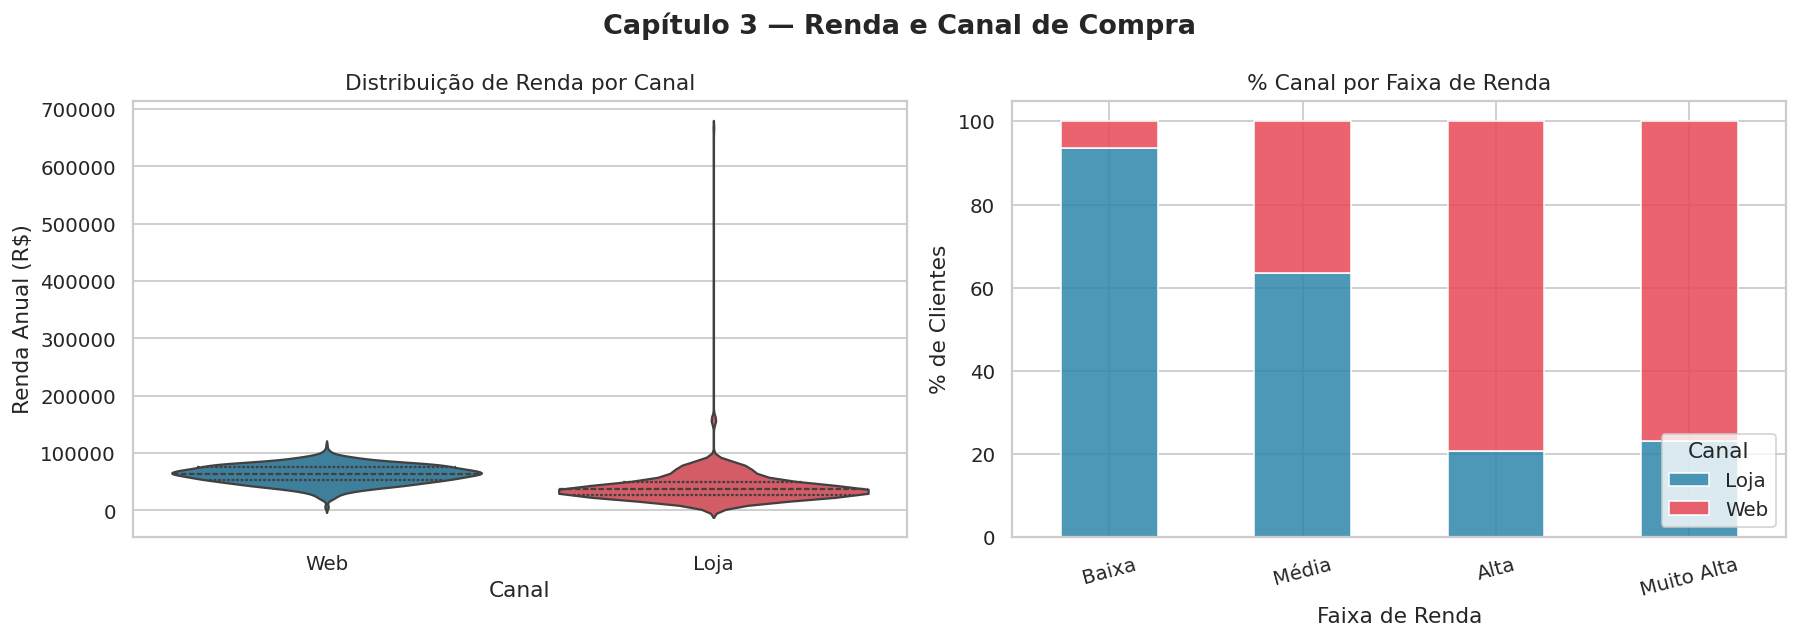


📌 INSIGHT 3:
   Clientes de renda mais alta apresentam maior propensão ao canal web.
   Nas faixas de renda baixa e média, a loja física ainda tem participação
   relevante — sugerindo que a barreira digital pode ter componente
   socioeconômico, além do etário.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 CAPÍTULO 4 — RECÊNCIA E VISITAS AO SITE
 Clientes web são mais engajados?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



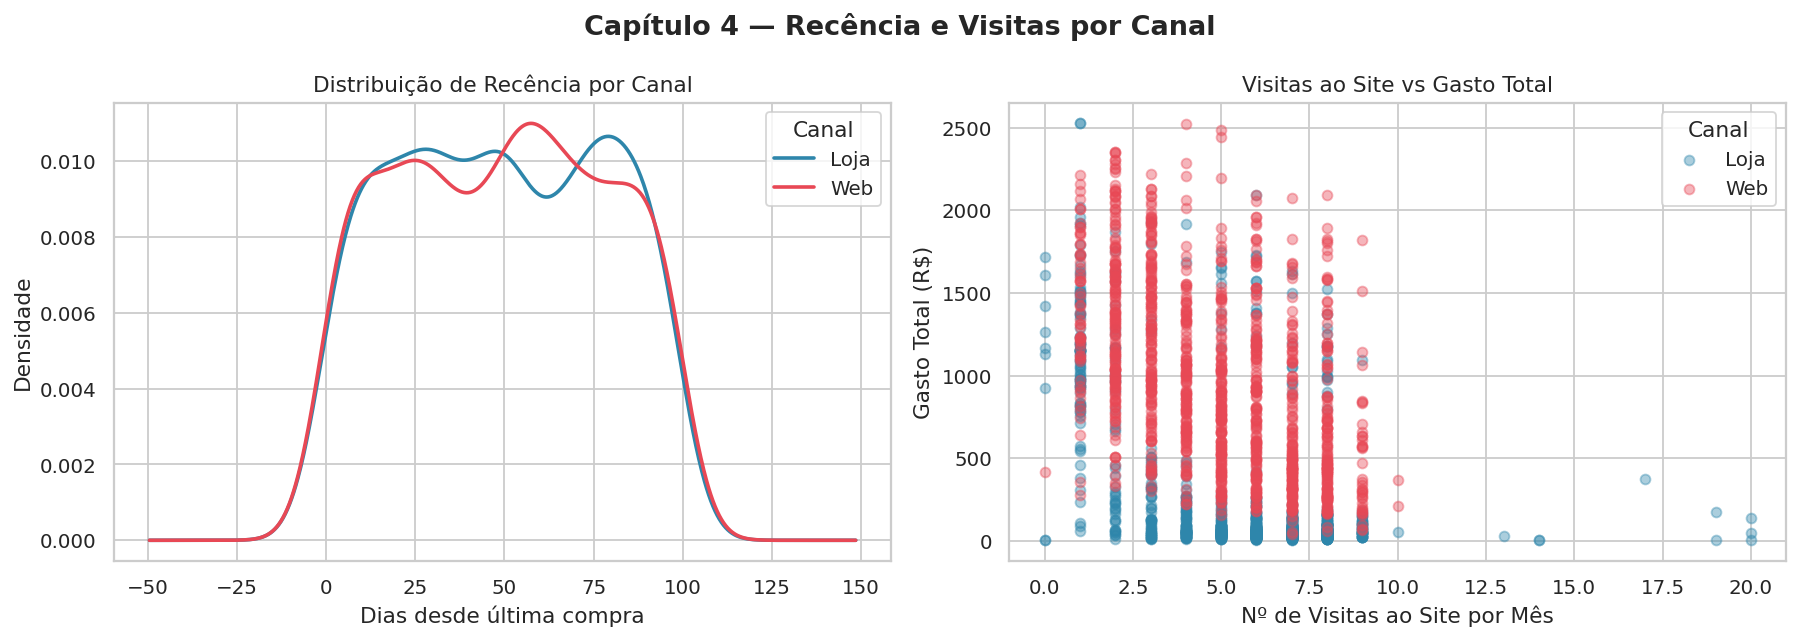


📌 INSIGHT 4:
   A distribuição de recência é semelhante entre os canais, indicando que
   a frequência de retorno não distingue fortemente os perfis.
   Porém, clientes web com alto número de visitas mensais ao site concentram
   os maiores gastos totais — reforçando que engajamento digital se converte
   em receita para o e-commerce.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 CAPÍTULO 5 — PAINEL INTERATIVO (Plotly)
 Explorando a relação Renda × Gasto × Canal
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



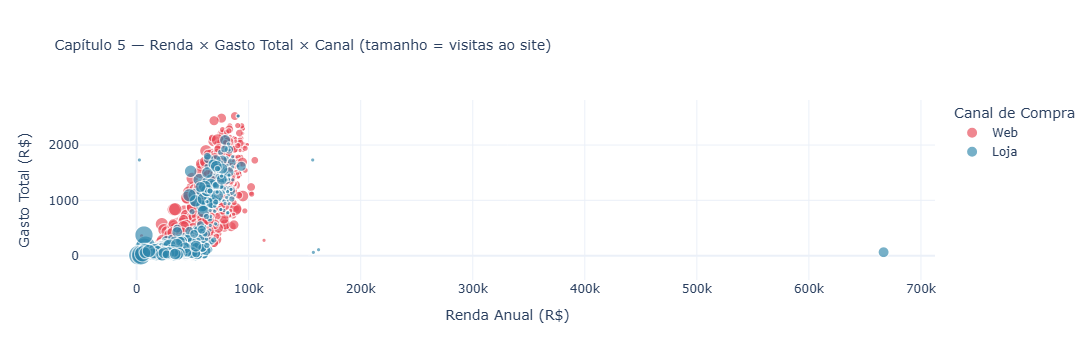


📌 INSIGHT 5 (SÍNTESE):
   O painel interativo confirma a narrativa construída ao longo da análise:

   ✅ Clientes web tendem a ter renda e gasto total maiores.
   ✅ O tamanho das bolhas (visitas ao site) é maior entre compradores web —
      mostrando que o engajamento digital precede e prediz a compra online.
   ✅ Clientes de loja com alta renda existem, mas são menos engajados digitalmente.

   👉 CONCLUSÃO ESTRATÉGICA:
      Para aumentar conversões web, a empresa deve focar em:
      (1) Clientes de renda média-alta ainda não convertidos ao online;
      (2) Estratégias de engajamento digital para faixas etárias mais velhas;
      (3) Personalização de ofertas para os top-spenders já presentes no web.



In [25]:
# 
sns.set_theme(style="whitegrid", palette="muted")
CORES = {"loja": "#2E86AB", "web": "#E84855", "neutro": "#F4A261"}
plt.rcParams.update({"figure.dpi": 130, "font.family": "DejaVu Sans"})

df_eda = df.copy()

# Garante a coluna Age
if 'Age' not in df_eda.columns:
    df_eda['Age'] = 2026 - df_eda['Year_Birth']
    
# Gasto total
df_eda['TotalSpent'] = (df_eda['MntWines'] + df_eda['MntFruits'] +
                         df_eda['MntMeatProducts'] + df_eda['MntFishProducts'] +
                         df_eda['MntSweetProducts'] + df_eda['MntGoldProds'])

# Faixa etária
bins   = [0, 35, 50, 65, 100]
labels = ['Jovem (≤35)', 'Adulto (36–50)', 'Meia-idade (51–65)', 'Sênior (>65)']
df_eda['FaixaEtaria'] = pd.cut(df_eda['Age'], bins=bins, labels=labels)

# Faixa de renda
bins_r   = [0, 30000, 55000, 80000, 999999]
labels_r = ['Baixa', 'Média', 'Alta', 'Muito Alta']
df_eda['FaixaRenda'] = pd.cut(df_eda['Income'], bins=bins_r, labels=labels_r)

# Canal dominante
df_eda['CanalDominante'] = np.where(df_eda['WebPurchases'] == 1, 'Web', 'Loja')

print("Pré-processamento complementar concluído.")
print(f"Clientes Web : {(df_eda['CanalDominante']=='Web').sum()}")
print(f"Clientes Loja: {(df_eda['CanalDominante']=='Loja').sum()}")


# VISÃO GERAL: QUEM COMPRA ONDE?
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 CAPÍTULO 1 — VISÃO GERAL: QUEM COMPRA ONDE?
 Qual canal concentra mais clientes? Há perfis distintos?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Capítulo 1 — Distribuição por Canal de Compra", fontsize=15, fontweight='bold', y=1.02)

# 1a) Pizza — proporção de canal
canal_counts = df_eda['CanalDominante'].value_counts()
axes[0].pie(canal_counts, labels=canal_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=[CORES['web'], CORES['loja']],
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title("Proporção de Canal Dominante")

# 1b) Countplot por faixa etária e canal
sns.countplot(data=df_eda, x='FaixaEtaria', hue='CanalDominante',
              palette=[CORES['loja'], CORES['web']], ax=axes[1])
axes[1].set_title("Canal Dominante por Faixa Etária")
axes[1].set_xlabel("Faixa Etária")
axes[1].set_ylabel("Nº de Clientes")
axes[1].legend(title="Canal")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("""
📌 INSIGHT 1:
   Aproximadamente metade dos clientes realizou ao menos uma compra online (Web).
   Clientes mais jovens apresentam maior adesão ao canal web, enquanto o público
   sênior ainda favorece a loja física — um padrão clássico de comportamento digital.
""")


# COMPORTAMENTO DE GASTO POR CANAL
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 CAPÍTULO 2 — COMPORTAMENTO DE GASTO POR CANAL
 Clientes web gastam mais? Em quais categorias?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Capítulo 2 — Gasto Total e por Categoria", fontsize=15, fontweight='bold')

# 2a) Boxplot — gasto total por canal
sns.boxplot(data=df_eda, x='CanalDominante', y='TotalSpent',
            palette=[CORES['loja'], CORES['web']], ax=axes[0])
axes[0].set_title("Gasto Total por Canal Dominante")
axes[0].set_xlabel("Canal")
axes[0].set_ylabel("Gasto Total (R$)")

# 2b) Barplot — média de gasto por categoria e canal
cats = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
labels_cats = ['Vinhos','Frutas','Carnes','Peixes','Doces','Ouro']
medias = df_eda.groupby('CanalDominante')[cats].mean().T
medias.index = labels_cats

x = np.arange(len(labels_cats))
w = 0.35
axes[1].bar(x - w/2, medias['Loja'], w, label='Loja', color=CORES['loja'], alpha=0.85)
axes[1].bar(x + w/2, medias['Web'],  w, label='Web',  color=CORES['web'],  alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_cats, rotation=15)
axes[1].set_title("Gasto Médio por Categoria e Canal")
axes[1].set_ylabel("Gasto Médio (R$)")
axes[1].legend(title="Canal")

plt.tight_layout()
plt.show()

print("""
📌 INSIGHT 2:
   Clientes web tendem a ter maior gasto total mediano em comparação aos
   exclusivos da loja. Vinhos e Carnes lideram o gasto em ambos os canais,
   mas a diferença é mais pronunciada entre compradores online — indicando
   que o canal web atrai um perfil de maior valor para o negócio.
""")


# RENDA E CANAL: O PODER DE COMPRA IMPORTA?
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 CAPÍTULO 3 — RENDA E CANAL
 A renda influencia a escolha do canal?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Capítulo 3 — Renda e Canal de Compra", fontsize=15, fontweight='bold')

# 3a) Violinplot renda x canal
df_plot = df_eda[df_eda['Income'].notna()]
sns.violinplot(data=df_plot, x='CanalDominante', y='Income',
               palette=[CORES['loja'], CORES['web']], inner='quartile', ax=axes[0])
axes[0].set_title("Distribuição de Renda por Canal")
axes[0].set_xlabel("Canal")
axes[0].set_ylabel("Renda Anual (R$)")

# 3b) Stacked bar — faixa de renda x canal
renda_canal = (df_eda.groupby(['FaixaRenda','CanalDominante'])
                      .size().unstack(fill_value=0))
renda_canal_pct = renda_canal.div(renda_canal.sum(axis=1), axis=0) * 100
renda_canal_pct.plot(kind='bar', stacked=True, ax=axes[1],
                     color=[CORES['loja'], CORES['web']], alpha=0.85)
axes[1].set_title("% Canal por Faixa de Renda")
axes[1].set_xlabel("Faixa de Renda")
axes[1].set_ylabel("% de Clientes")
axes[1].legend(title="Canal", loc='lower right')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("""
📌 INSIGHT 3:
   Clientes de renda mais alta apresentam maior propensão ao canal web.
   Nas faixas de renda baixa e média, a loja física ainda tem participação
   relevante — sugerindo que a barreira digital pode ter componente
   socioeconômico, além do etário.
""")


#  RECÊNCIA E ENGAJAMENTO
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 CAPÍTULO 4 — RECÊNCIA E VISITAS AO SITE
 Clientes web são mais engajados?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Capítulo 4 — Recência e Visitas por Canal", fontsize=15, fontweight='bold')

# 4a) KDE — Recência por canal
for canal, cor in [('Loja', CORES['loja']), ('Web', CORES['web'])]:
    subset = df_eda[df_eda['CanalDominante'] == canal]['Recency']
    subset.plot.kde(ax=axes[0], label=canal, color=cor, linewidth=2)
axes[0].set_title("Distribuição de Recência por Canal")
axes[0].set_xlabel("Dias desde última compra")
axes[0].set_ylabel("Densidade")
axes[0].legend(title="Canal")

# 4b) Scatter — Visitas ao site vs Gasto Total
scatter_data = df_eda[df_eda['Income'].notna()]
for canal, cor in [('Loja', CORES['loja']), ('Web', CORES['web'])]:
    sub = scatter_data[scatter_data['CanalDominante'] == canal]
    axes[1].scatter(sub['NumWebVisitsMonth'], sub['TotalSpent'],
                    alpha=0.4, color=cor, label=canal, s=30)
axes[1].set_title("Visitas ao Site vs Gasto Total")
axes[1].set_xlabel("Nº de Visitas ao Site por Mês")
axes[1].set_ylabel("Gasto Total (R$)")
axes[1].legend(title="Canal")

plt.tight_layout()
plt.show()

print("""
📌 INSIGHT 4:
   A distribuição de recência é semelhante entre os canais, indicando que
   a frequência de retorno não distingue fortemente os perfis.
   Porém, clientes web com alto número de visitas mensais ao site concentram
   os maiores gastos totais — reforçando que engajamento digital se converte
   em receita para o e-commerce.
""")


# CAPÍTULO 5 — PLOTLY: PAINEL INTERATIVO FINAL
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 CAPÍTULO 5 — PAINEL INTERATIVO (Plotly)
 Explorando a relação Renda × Gasto × Canal
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

df_plotly = df_eda[df_eda['Income'].notna()].copy()

fig_plotly = px.scatter(
    df_plotly,
    x='Income',
    y='TotalSpent',
    color='CanalDominante',
    size='NumWebVisitsMonth',
    hover_data=['Age', 'Education', 'FaixaEtaria'],
    color_discrete_map={'Loja': CORES['loja'], 'Web': CORES['web']},
    opacity=0.65,
    title='Capítulo 5 — Renda × Gasto Total × Canal (tamanho = visitas ao site)',
    labels={
        'Income': 'Renda Anual (R$)',
        'TotalSpent': 'Gasto Total (R$)',
        'CanalDominante': 'Canal',
        'NumWebVisitsMonth': 'Visitas/mês'
    }
)
fig_plotly.update_layout(
    template='plotly_white',
    legend_title_text='Canal de Compra',
    title_font_size=14
)
fig_plotly.show()

print("""
📌 INSIGHT 5 (SÍNTESE):
   O painel interativo confirma a narrativa construída ao longo da análise:
   
   ✅ Clientes web tendem a ter renda e gasto total maiores.
   ✅ O tamanho das bolhas (visitas ao site) é maior entre compradores web —
      mostrando que o engajamento digital precede e prediz a compra online.
   ✅ Clientes de loja com alta renda existem, mas são menos engajados digitalmente.
   
   👉 CONCLUSÃO ESTRATÉGICA:
      Para aumentar conversões web, a empresa deve focar em:
      (1) Clientes de renda média-alta ainda não convertidos ao online;
      (2) Estratégias de engajamento digital para faixas etárias mais velhas;
      (3) Personalização de ofertas para os top-spenders já presentes no web.
""")


# ETAPA 2:


**Pré-processamento**

**Análise Correlação:** Verifique a correlação entre as váriaveis e análise se há espaço para retirar váriaveis que não te parecem importantes.

Variáveis analisadas (15):
['Income', 'Kidhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'WebPurchases', 'Age', 'TotalSpent']



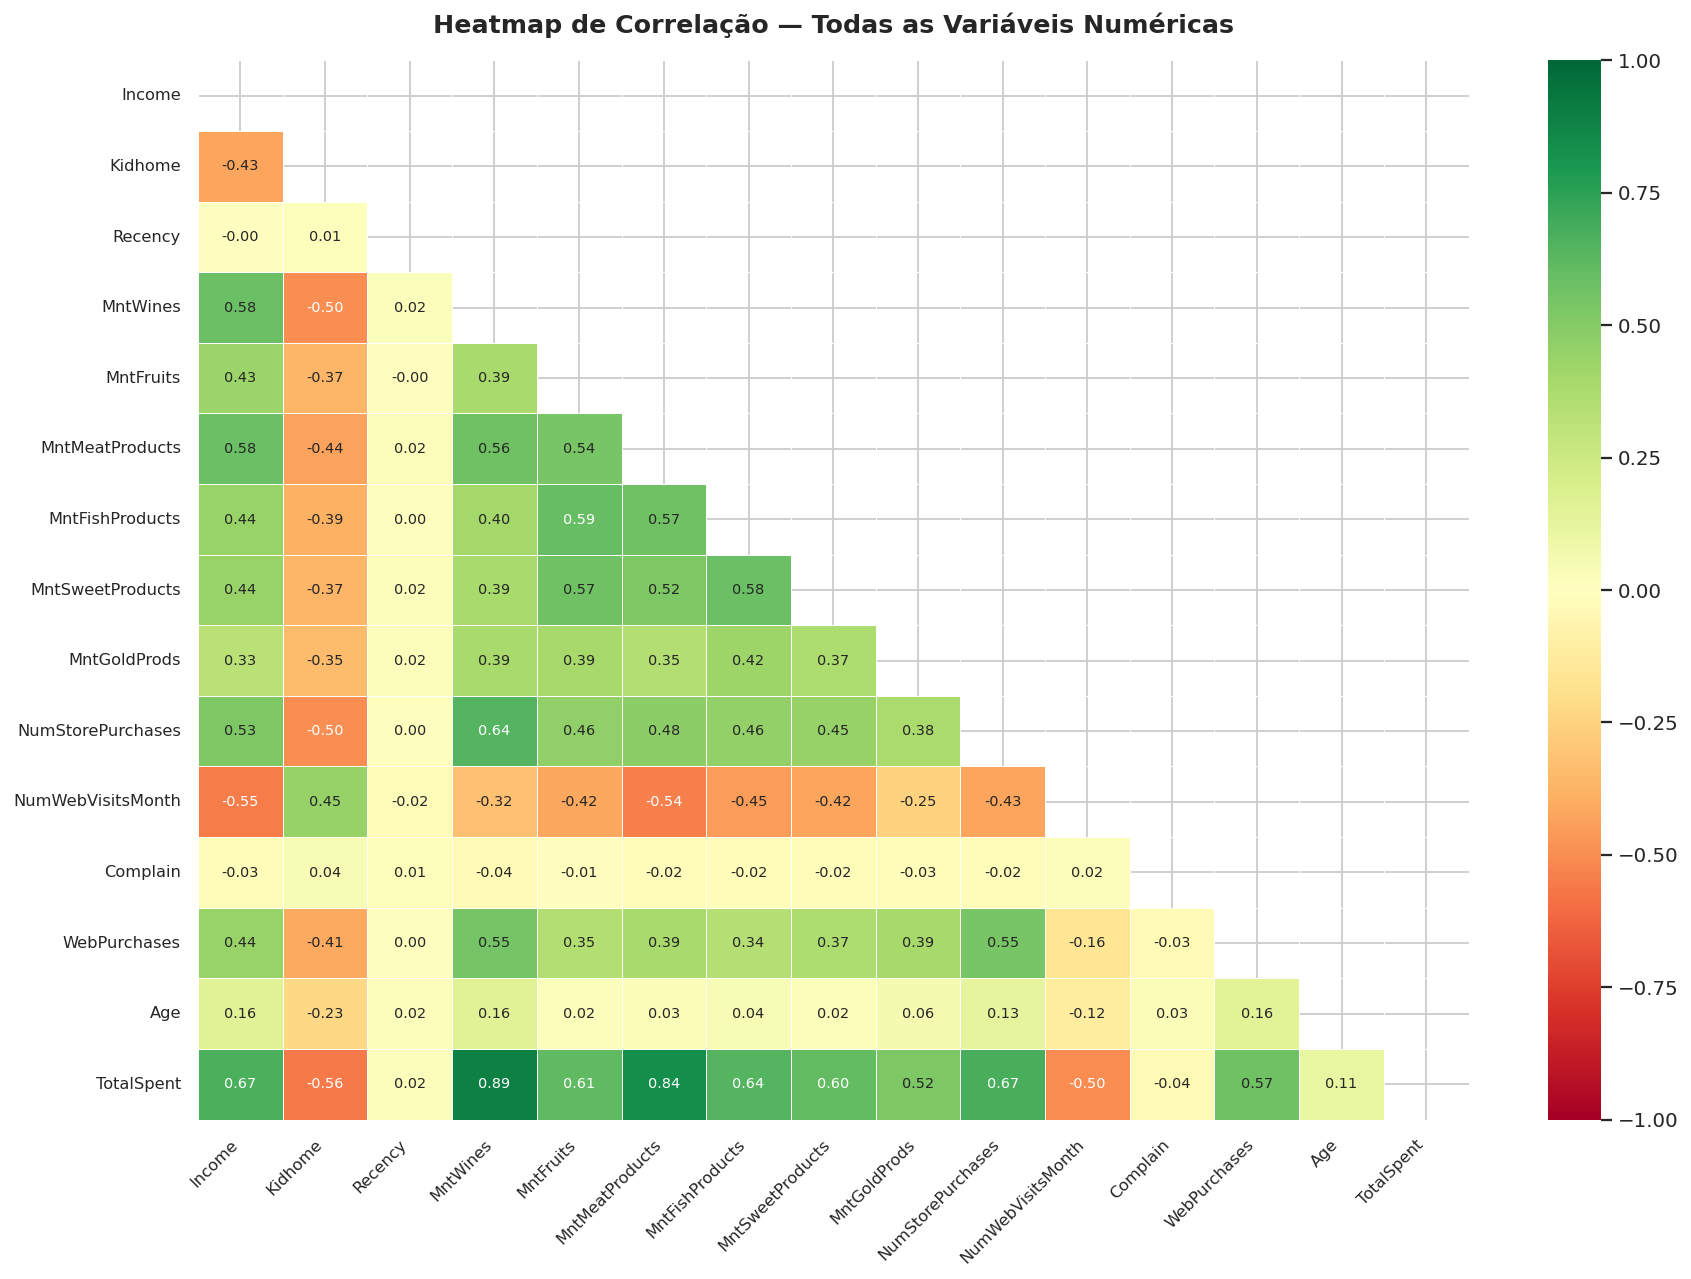

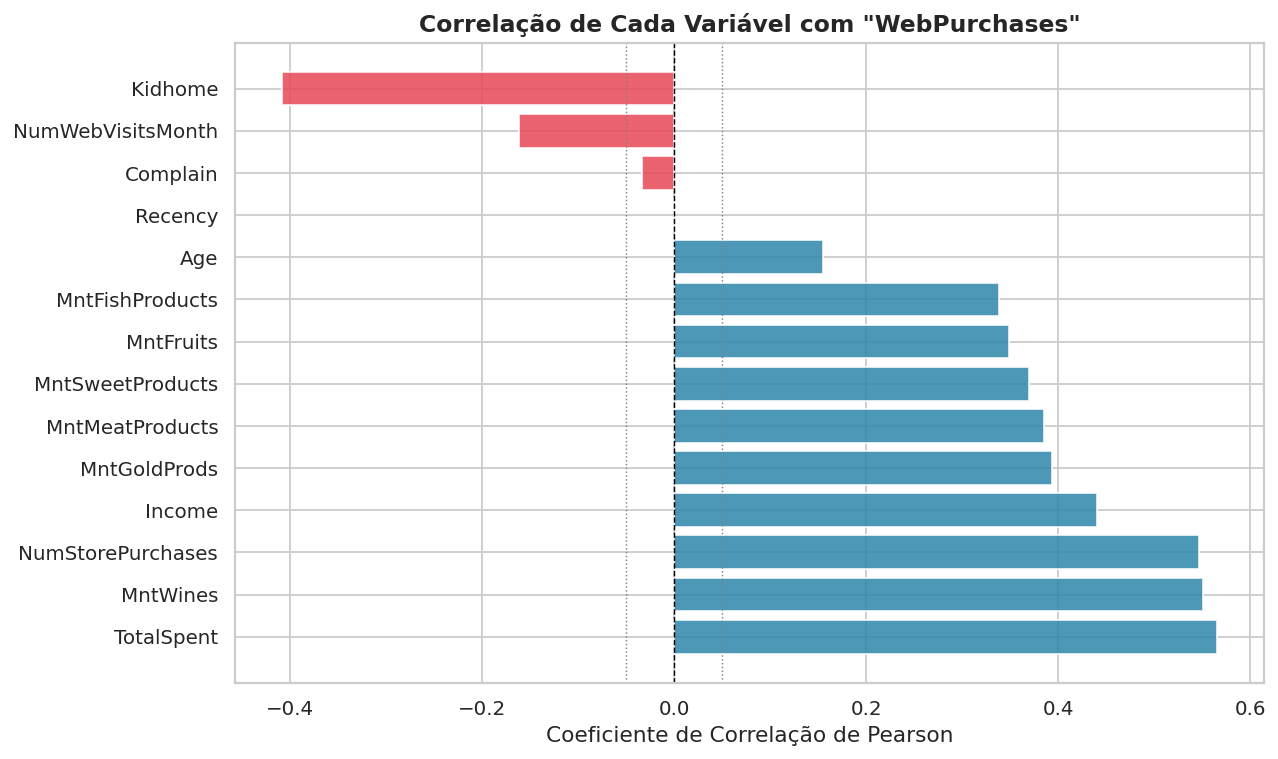

 PARES COM ALTA CORRELAÇÃO ENTRE SI (|r| > 0.70)
           Var1       Var2  Correlação
       MntWines TotalSpent    0.891839
MntMeatProducts TotalSpent    0.842965

 CORRELAÇÃO POINT-BISERIAL COM WebPurchases
 (mais adequada para target binária)
         Variável       r  p-value Significativa (p<0.05)
       TotalSpent  0.5652   0.0000                      ✅
         MntWines  0.5505   0.0000                      ✅
NumStorePurchases  0.5466   0.0000                      ✅
           Income  0.4403   0.0000                      ✅
          Kidhome -0.4081   0.0000                      ✅
     MntGoldProds  0.3936   0.0000                      ✅
  MntMeatProducts  0.3852   0.0000                      ✅
 MntSweetProducts  0.3697   0.0000                      ✅
        MntFruits  0.3488   0.0000                      ✅
  MntFishProducts  0.3387   0.0000                      ✅
NumWebVisitsMonth -0.1612   0.0000                      ✅
              Age  0.1552   0.0000                      

In [28]:
# Variável alvo 
TARGET = 'WebPurchases'

# Seleciona apenas numéricas 
df_corr = df_eda.select_dtypes(include=[np.number]).copy()

# Remove colunas auxiliares que não entram no modelo
cols_remover = ['Year_Birth', 'Income_original', 'Income_outlier_flag',
                'Year_Birth_out_of_range']
df_corr.drop(columns=[c for c in cols_remover if c in df_corr.columns], inplace=True)

print(f"Variáveis analisadas ({len(df_corr.columns)}):\n{df_corr.columns.tolist()}\n")


# GRÁFICO 1 — HEATMAP DE CORRELAÇÃO GERAL

corr_matrix = df_corr.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title('Heatmap de Correlação — Todas as Variáveis Numéricas',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


# GRÁFICO 2 — CORRELAÇÃO COM A VARIÁVEL ALVO (WebPurchases)

corr_target = (corr_matrix[TARGET]
               .drop(TARGET)
               .sort_values(ascending=False))

cores = ['#2E86AB' if v > 0 else '#E84855' for v in corr_target]

plt.figure(figsize=(10, 6))
bars = plt.barh(corr_target.index, corr_target.values, color=cores, alpha=0.85)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(x=0.05,  color='gray', linewidth=0.8, linestyle=':')
plt.axvline(x=-0.05, color='gray', linewidth=0.8, linestyle=':')
plt.title(f'Correlação de Cada Variável com "{TARGET}"',
          fontsize=13, fontweight='bold')
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.tight_layout()
plt.show()


# GRÁFICO 3 — CORRELAÇÕES ALTAS ENTRE PREDITORES (MULTICOLINEARIDADE)
## Pares com |correlação| > 0.7 (excluindo diagonal e target)

corr_abs = corr_matrix.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

pares_altos = (upper.stack()
                     .reset_index()
                     .rename(columns={'level_0':'Var1','level_1':'Var2', 0:'Correlação'})
                     .query('Correlação > 0.7')
                     .sort_values('Correlação', ascending=False))

print("=" * 55)
print(" PARES COM ALTA CORRELAÇÃO ENTRE SI (|r| > 0.70)")
print("=" * 55)
if pares_altos.empty:
    print("Nenhum par com correlação acima de 0.70 encontrado.")
else:
    print(pares_altos.to_string(index=False))


# ANÁLISE ESTATÍSTICA — POINT-BISERIAL COM A TARGET

print("\n" + "=" * 55)
print(" CORRELAÇÃO POINT-BISERIAL COM WebPurchases")
print(" (mais adequada para target binária)")
print("=" * 55)

resultados = []
preditoras = [c for c in df_corr.columns if c != TARGET]

for col in preditoras:
    subset = df_corr[[col, TARGET]].dropna()
    r, p = stats.pointbiserialr(subset[TARGET], subset[col])
    resultados.append({'Variável': col, 'r': round(r, 4), 'p-value': round(p, 4),
                       'Significativa (p<0.05)': '✅' if p < 0.05 else '❌'})

df_pb = (pd.DataFrame(resultados)
           .sort_values('r', key=abs, ascending=False))
print(df_pb.to_string(index=False))



# DECISÃO: VARIÁVEIS CANDIDATAS A REMOÇÃO
## Critério: |r| < 0.05 com target E não significativa estatisticamente

fracas = df_pb[(df_pb['r'].abs() < 0.05) & (df_pb['Significativa (p<0.05)'] == '❌')]

print("\n" + "=" * 55)
print(" VARIÁVEIS CANDIDATAS À REMOÇÃO")
print(" Critério: |r| < 0.05 com target e p-value ≥ 0.05")
print("=" * 55)
if fracas.empty:
    print("Nenhuma variável atende ao critério de remoção.")
else:
    print(fracas[['Variável','r','p-value']].to_string(index=False))



**Pré-processamento**

**Codificação de Variáveis Categóricas:** Transformar variáveis categóricas em um formato que os modelos de machine learning possam interpretar.

In [30]:
df_model = df_eda.copy()


# DIAGNÓSTICO INICIAL 
cats = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
print("=" * 55)
print(f" VARIÁVEIS CATEGÓRICAS ENCONTRADAS ({len(cats)})")
print("=" * 55)
for col in cats:
    print(f"  • {col:20s} → {df_model[col].nunique()} categorias: {df_model[col].unique().tolist()}")


# 1) EDUCATION — Ordinal Encoding (hierarquia natural)
#    Basic < 2n Cycle < Graduation < Master < PhD
education_order = {
    'Basic'      : 1,
    '2n Cycle'   : 2,
    'Graduation' : 3,
    'Master'     : 4,
    'PhD'        : 5
}
df_model['Education_enc'] = df_model['Education'].map(education_order)

print("\n" + "=" * 55)
print(" EDUCATION — Ordinal Encoding")
print("=" * 55)
print(pd.DataFrame({'Original': list(education_order.keys()),
                    'Código'  : list(education_order.values())}
                   ).to_string(index=False))


# 2) MARITAL_STATUS — One-Hot Encoding (sem hierarquia)

# Consolida categorias raras em 'Other'
status_validos = ['Single', 'Together', 'Married', 'Divorced', 'Widow']
df_model['Marital_Status_clean'] = df_model['Marital_Status'].where(
    df_model['Marital_Status'].isin(status_validos), other='Other'
)

marital_dummies = pd.get_dummies(
    df_model['Marital_Status_clean'],
    prefix='Marital',
    drop_first=True       # evita dummy trap
)

df_model = pd.concat([df_model, marital_dummies], axis=1)

print("\n" + "=" * 55)
print(" MARITAL_STATUS — One-Hot Encoding")
print("=" * 55)
print(f"Categorias originais : {df_model['Marital_Status'].unique().tolist()}")
print(f"Categorias após clean: {df_model['Marital_Status_clean'].unique().tolist()}")
print(f"Dummies criadas      : {marital_dummies.columns.tolist()}")


# 3) FAIXAETARIA E FAIXARENDA — Ordinal Encoding
#    (criadas na EDA, têm ordem natural)
faixa_etaria_order = {
    'Jovem (≤35)'       : 1,
    'Adulto (36–50)'    : 2,
    'Meia-idade (51–65)': 3,
    'Sênior (>65)'      : 4
}
faixa_renda_order = {
    'Baixa'     : 1,
    'Média'     : 2,
    'Alta'      : 3,
    'Muito Alta': 4
}

if 'FaixaEtaria' in df_model.columns:
    df_model['FaixaEtaria_enc'] = df_model['FaixaEtaria'].map(faixa_etaria_order)

if 'FaixaRenda' in df_model.columns:
    df_model['FaixaRenda_enc'] = df_model['FaixaRenda'].map(faixa_renda_order)

print("\n" + "=" * 55)
print(" FAIXAETARIA e FAIXARENDA — Ordinal Encoding")
print("=" * 55)
print("FaixaEtaria:", faixa_etaria_order)
print("FaixaRenda :", faixa_renda_order)


# 4) REMOVE COLUNAS ORIGINAIS E AUXILIARES
#    (substituídas pelas encoded)

cols_drop = [
    'Education',            # substituída por Education_enc
    'Marital_Status',       # substituída por dummies
    'Marital_Status_clean', # auxiliar
    'FaixaEtaria',          # substituída por FaixaEtaria_enc
    'FaixaRenda',           # substituída por FaixaRenda_enc
    'CanalDominante',       # string auxiliar da EDA
    'Year_Birth',           # substituída por Age
    'Income_original',      # redundante com Income
    'Income_outlier_flag',  # auxiliar
    'Year_Birth_out_of_range', # auxiliar
    'Income_log',           # usaremos Income direto (já tratado)
]

cols_drop_existentes = [c for c in cols_drop if c in df_model.columns]
df_model.drop(columns=cols_drop_existentes, inplace=True)

print("\n" + "=" * 55)
print(" COLUNAS REMOVIDAS")
print("=" * 55)
print(f"  {cols_drop_existentes}")



# RESULTADO FINAL

print("\n" + "=" * 55)
print(f" DATASET FINAL PARA MODELAGEM")
print(f" Shape: {df_model.shape}")
print("=" * 55)
print(df_model.dtypes.to_string())

print("\nMissing values restantes:")
missing = df_model.isnull().sum()
print(missing[missing > 0] if missing.any() else "  Nenhum missing encontrado ✅")

print("\nPrimeiras linhas do df_model:")
print(df_model.head(3).to_string())



 VARIÁVEIS CATEGÓRICAS ENCONTRADAS (5)
  • Education            → 5 categorias: ['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
  • Marital_Status       → 8 categorias: ['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd', 'YOLO']
  • FaixaEtaria          → 4 categorias: ['Sênior (>65)', 'Meia-idade (51–65)', 'Adulto (36–50)', 'Jovem (≤35)', nan]
  • FaixaRenda           → 4 categorias: ['Alta', 'Média', 'Baixa', nan, 'Muito Alta']
  • CanalDominante       → 2 categorias: ['Web', 'Loja']

 EDUCATION — Ordinal Encoding
  Original  Código
     Basic       1
  2n Cycle       2
Graduation       3
    Master       4
       PhD       5

 MARITAL_STATUS — One-Hot Encoding
Categorias originais : ['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd', 'YOLO']
Categorias após clean: ['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Other']
Dummies criadas      : ['Marital_Married', 'Marital_Other', 'Marital_Single', 'Marital_Together', 'Marital_Wi

**Pré-processamento**

**Separe a base em Y, X e Treino e teste:**: Faça a separação da base.

In [32]:
# 1) DEFINE X e Y
TARGET = 'WebPurchases'

# Remove linhas com missing antes de separar
df_final = df_model.dropna().copy()

X = df_final.drop(columns=[TARGET])
Y = df_final[TARGET]

print("=" * 55)
print(" DEFINIÇÃO DE X e Y")
print("=" * 55)
print(f"  Shape X (preditoras) : {X.shape}")
print(f"  Shape Y (alvo)       : {Y.shape}")
print(f"\n  Variável alvo: '{TARGET}'")
print(f"  Distribuição da classe:")
print(Y.value_counts().to_string())
print(f"\n  Proporção:")
print((Y.value_counts(normalize=True) * 100).round(2).to_string())
print(f"\n  Preditoras utilizadas ({len(X.columns)}):")
for col in X.columns:
    print(f"    • {col}")


# 2) SEPARAÇÃO TREINO E TESTE — 80/20 estratificado

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.20,
    random_state=42,
    stratify=Y        # mantém proporção das classes em ambos os conjuntos
)

print("\n" + "=" * 55)
print(" SEPARAÇÃO TREINO / TESTE (80% / 20%)")
print("=" * 55)
print(f"  Treino  → X: {X_train.shape} | Y: {Y_train.shape}")
print(f"  Teste   → X: {X_test.shape}  | Y: {Y_test.shape}")

print(f"\n  Proporção Y no Treino:")
print((Y_train.value_counts(normalize=True) * 100).round(2).to_string())
print(f"\n  Proporção Y no Teste:")
print((Y_test.value_counts(normalize=True) * 100).round(2).to_string())


# 3) NORMALIZAÇÃO — StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),       # NUNCA fit no teste — apenas transform
    columns=X_test.columns,
    index=X_test.index
)

print("\n" + "=" * 55)
print(" NORMALIZAÇÃO — StandardScaler")
print("=" * 55)
print("  ✅ fit_transform aplicado no TREINO")
print("  ✅ transform aplicado no TESTE (sem vazamento de dados)")
print(f"\n  Exemplo — médias após escala (X_train_scaled):")
print(X_train_scaled.mean().round(4).to_string())


# RESUMO FINAL

print("\n" + "=" * 55)
print(" RESUMO DA SEPARAÇÃO")
print("=" * 55)
print(f"""
  Dataset completo  : {df_final.shape[0]} linhas × {df_final.shape[1]} colunas
  ├── Treino        : {X_train.shape[0]} linhas ({X_train.shape[0]/df_final.shape[0]*100:.0f}%)
  └── Teste         : {X_test.shape[0]} linhas ({X_test.shape[0]/df_final.shape[0]*100:.0f}%)

  Objetos disponíveis para modelagem:
    • X_train        → preditoras treino (original)
    • X_test         → preditoras teste  (original)
    • X_train_scaled → preditoras treino (normalizado)
    • X_test_scaled  → preditoras teste  (normalizado)
    • Y_train        → alvo treino
    • Y_test         → alvo teste
    • scaler         → objeto para transformar novos dados futuros
""")


 DEFINIÇÃO DE X e Y
  Shape X (preditoras) : (2213, 22)
  Shape Y (alvo)       : (2213,)

  Variável alvo: 'WebPurchases'
  Distribuição da classe:
WebPurchases
1    1117
0    1096

  Proporção:
WebPurchases
1    50.47
0    49.53

  Preditoras utilizadas (22):
    • Income
    • Kidhome
    • Recency
    • MntWines
    • MntFruits
    • MntMeatProducts
    • MntFishProducts
    • MntSweetProducts
    • MntGoldProds
    • NumStorePurchases
    • NumWebVisitsMonth
    • Complain
    • Age
    • TotalSpent
    • Education_enc
    • Marital_Married
    • Marital_Other
    • Marital_Single
    • Marital_Together
    • Marital_Widow
    • FaixaEtaria_enc
    • FaixaRenda_enc

 SEPARAÇÃO TREINO / TESTE (80% / 20%)
  Treino  → X: (1770, 22) | Y: (1770,)
  Teste   → X: (443, 22)  | Y: (443,)

  Proporção Y no Treino:
WebPurchases
1    50.45
0    49.55

  Proporção Y no Teste:
WebPurchases
1    50.56
0    49.44

 NORMALIZAÇÃO — StandardScaler
  ✅ fit_transform aplicado no TREINO
  ✅ transform ap

**Pré-processamento**

**Realize a padronização dos dados**: Padronize os dados para garantir eficiência no modelo e eficácia.

Colunas mantidas: ['Income', 'Kidhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Age', 'TotalSpent', 'Education_enc']
Tipos restantes:
 Income               float64
Kidhome                int64
Recency                int64
MntWines               int64
MntFruits              int64
MntMeatProducts        int64
MntFishProducts        int64
MntSweetProducts       int64
MntGoldProds           int64
NumStorePurchases      int64
NumWebVisitsMonth      int64
Complain               int64
Age                    int64
TotalSpent             int64
Education_enc          int64

 DIAGNÓSTICO — ESCALA ATUAL (X_train)
                      Min       Max     Média       Std
Income             1730.0  666666.0  52361.39  25949.80
TotalSpent            5.0    2486.0    603.89    595.80
MntWines              0.0    1493.0    307.85    338.95
MntMeatProducts       0.0    1725.0    163

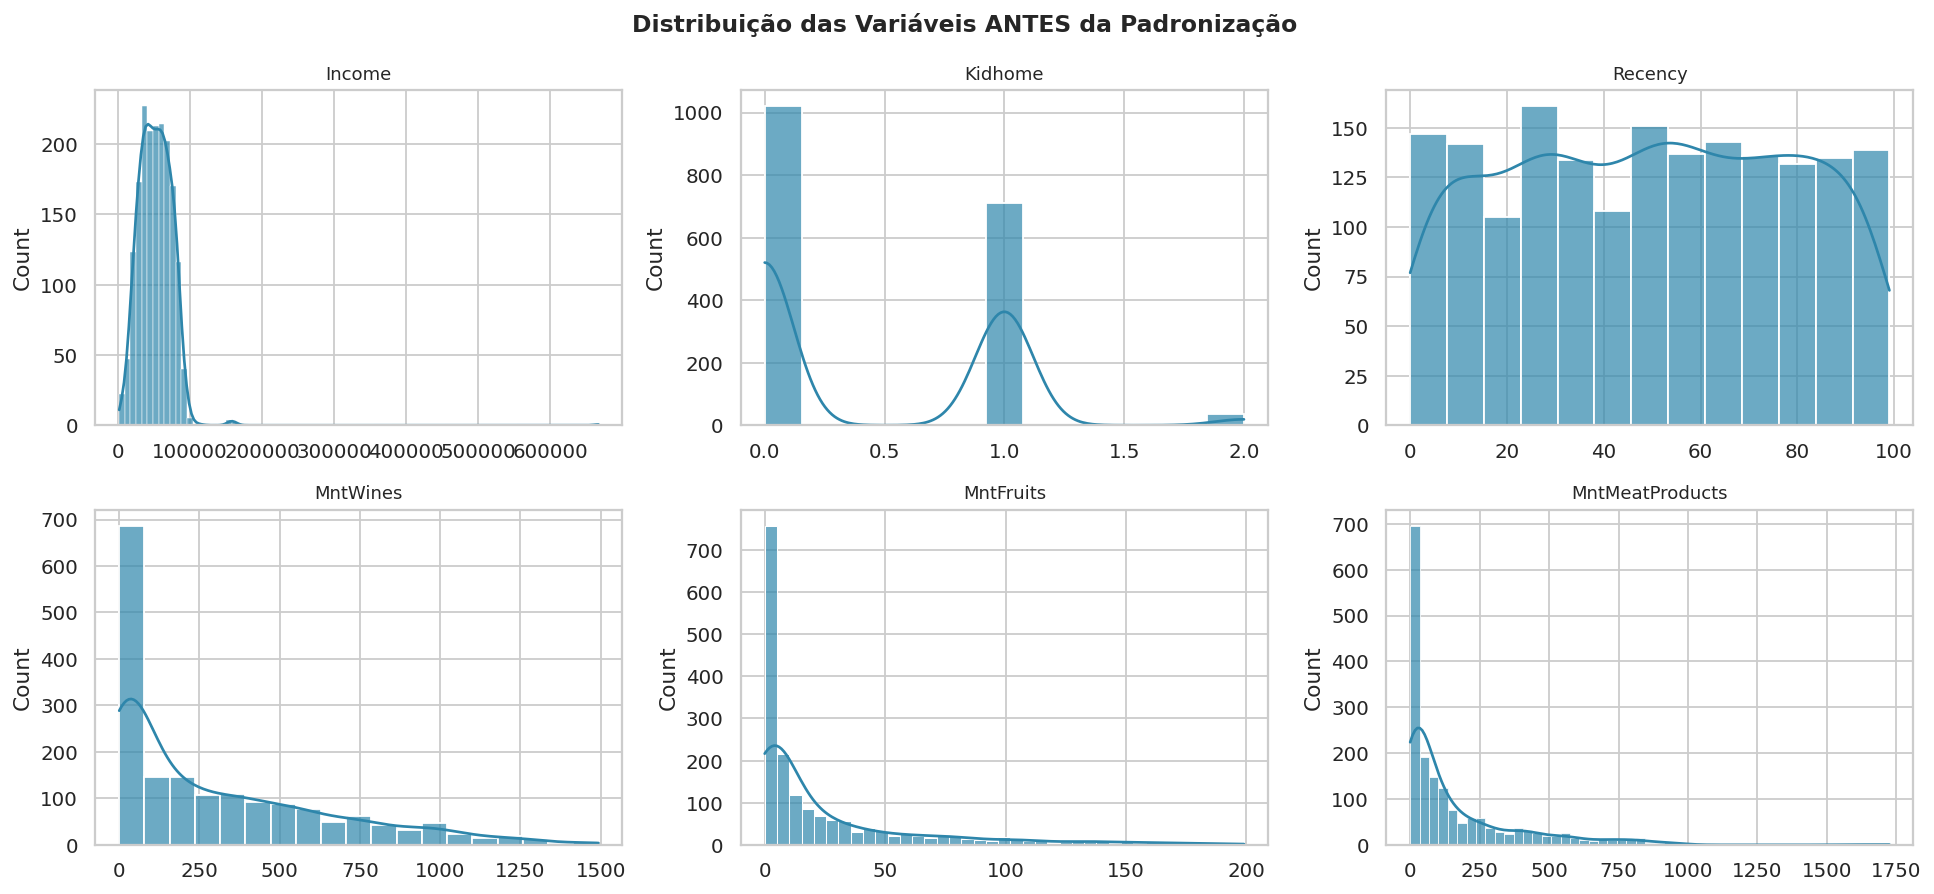


 COMPARATIVO DE ESTRATÉGIAS DE PADRONIZAÇÃO


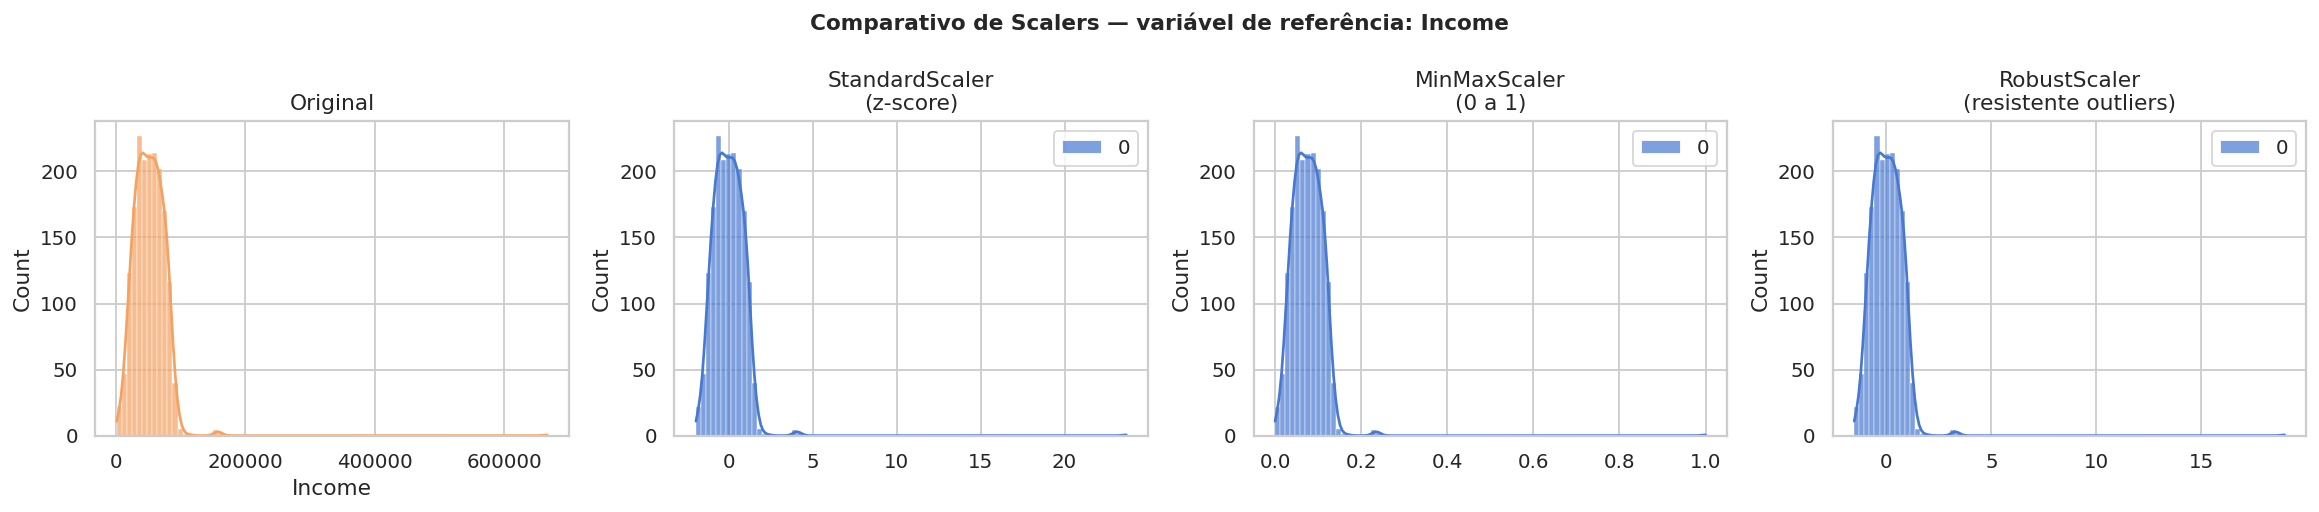

 ROBUSTSCALER APLICADO
  ✅ fit_transform → X_train_scaled
  ✅ transform     → X_test_scaled (sem data leakage)

 ESTATÍSTICAS X_train — ANTES vs DEPOIS
                   Média Antes  Std  Antes  Média Depois  Std  Depois
Income               52361.393   25949.798         0.028        0.800
TotalSpent             603.890     595.795         0.207        0.608
MntWines               307.854     338.951         0.267        0.701
MntMeatProducts        163.601     222.404         0.470        1.076
MntFishProducts         36.353      53.472         0.544        1.195
MntGoldProds            43.520      51.261         0.412        1.139
MntSweetProducts        26.498      40.275         0.583        1.268
MntFruits               26.064      39.262         0.583        1.267
Recency                 49.309      28.804        -0.014        0.588
Age                     57.129      11.653         0.063        0.647
NumStorePurchases        5.825       3.251         0.165        0.650
NumWebVi

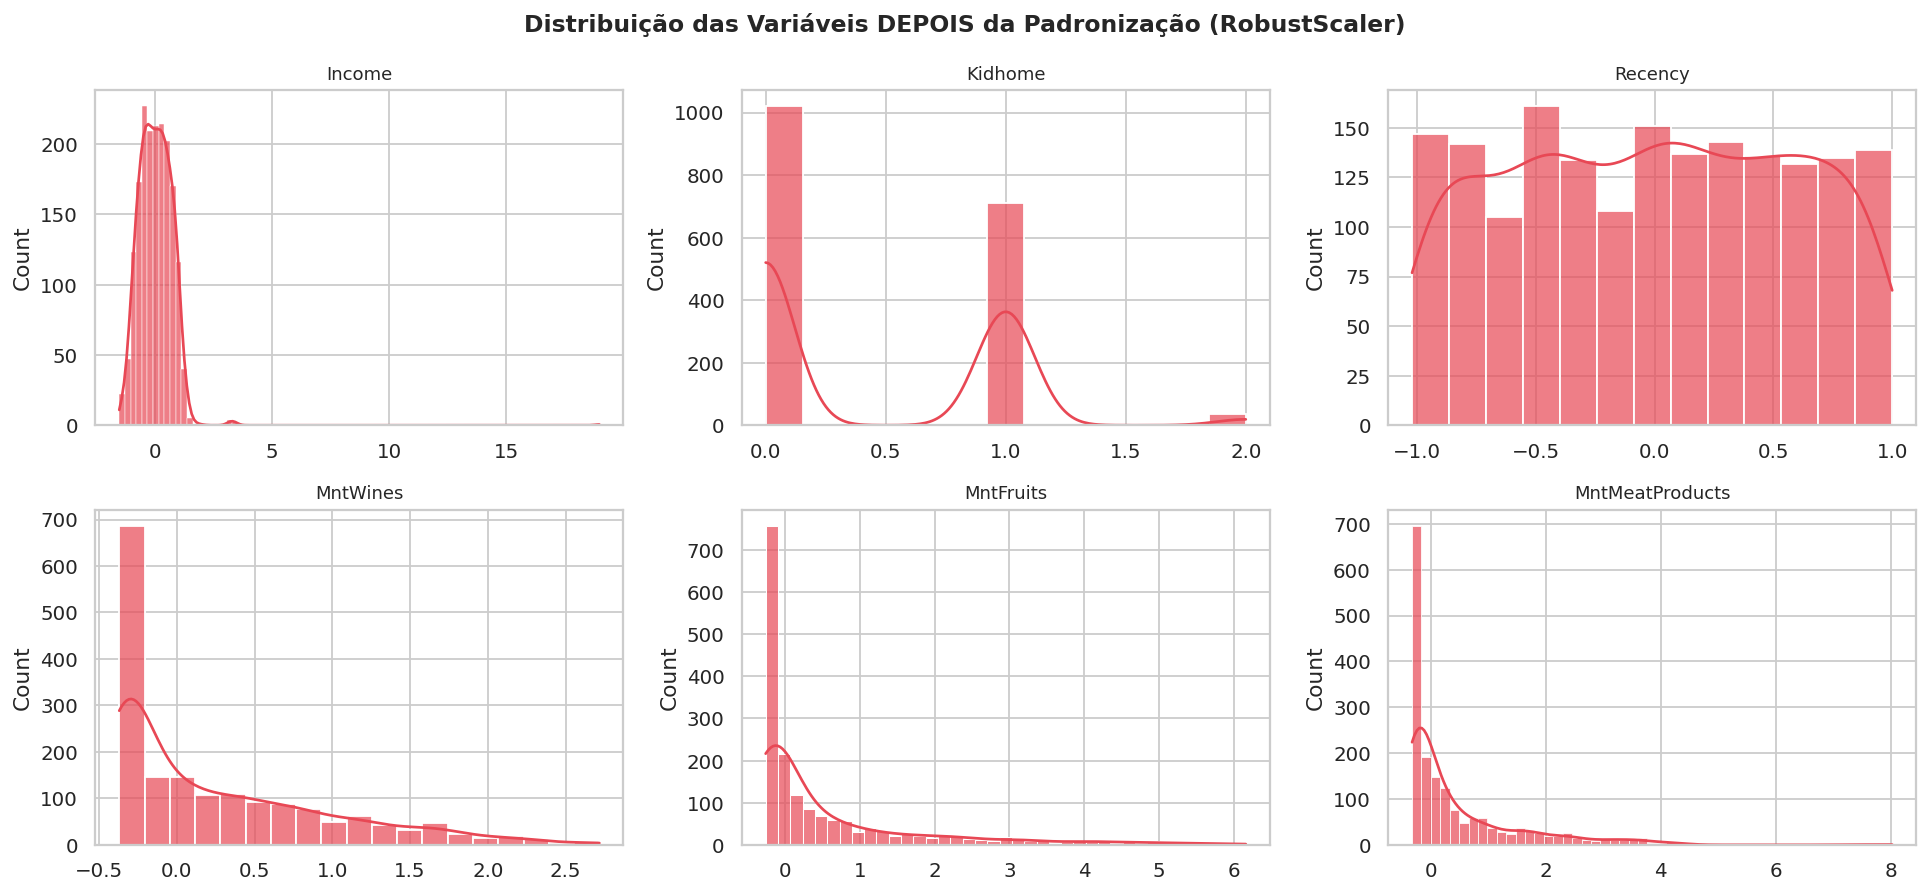

In [36]:
#  PADRONIZAÇÃO DOS DADOS 


X_train = X_train.select_dtypes(include=[np.number]).copy()
X_test  = X_test.select_dtypes(include=[np.number]).copy()

print("Colunas mantidas:", X_train.columns.tolist())
print("Tipos restantes:\n", X_train.dtypes.to_string())


# 1) DIAGNÓSTICO — ESCALA ATUAL DAS VARIÁVEIS

print("\n" + "=" * 55)
print(" DIAGNÓSTICO — ESCALA ATUAL (X_train)")
print("=" * 55)

diagnostico = pd.DataFrame({
    'Min'   : X_train.min(),
    'Max'   : X_train.max(),
    'Média' : X_train.mean().round(2),
    'Std'   : X_train.std().round(2)
}).sort_values('Std', ascending=False)

print(diagnostico.to_string())

#  Visualiza distribuição antes da padronização 
cols_viz = X_train.columns[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Distribuição das Variáveis ANTES da Padronização',
             fontsize=13, fontweight='bold')
for ax, col in zip(axes.flatten(), cols_viz):
    sns.histplot(X_train[col], kde=True, ax=ax, color='#2E86AB', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()


# 2) COMPARATIVO ENTRE SCALERS

print("\n" + "=" * 55)
print(" COMPARATIVO DE ESTRATÉGIAS DE PADRONIZAÇÃO")
print("=" * 55)

scalers = {
    'StandardScaler\n(z-score)'           : StandardScaler(),
    'MinMaxScaler\n(0 a 1)'               : MinMaxScaler(),
    'RobustScaler\n(resistente outliers)' : RobustScaler()
}

col_ref = 'Income' if 'Income' in X_train.columns else X_train.columns[0]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(f'Comparativo de Scalers — variável de referência: {col_ref}',
             fontsize=12, fontweight='bold')

sns.histplot(X_train[col_ref], kde=True, ax=axes[0],
             color='#F4A261', alpha=0.7)
axes[0].set_title('Original')

for ax, (nome, sc) in zip(axes[1:], scalers.items()):
    col_scaled = sc.fit_transform(X_train[[col_ref]])
    sns.histplot(col_scaled, kde=True, ax=ax, color='#2E86AB', alpha=0.7)
    ax.set_title(nome)

plt.tight_layout()
plt.show()



# 3) APLICA ROBUSTSCALER — VERSÃO DEFINITIVA

robust_scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    robust_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    robust_scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("=" * 55)
print(" ROBUSTSCALER APLICADO")
print("=" * 55)
print("  ✅ fit_transform → X_train_scaled")
print("  ✅ transform     → X_test_scaled (sem data leakage)\n")


# 4) VALIDAÇÃO — ANTES vs DEPOIS

print("=" * 55)
print(" ESTATÍSTICAS X_train — ANTES vs DEPOIS")
print("=" * 55)

comparativo = pd.DataFrame({
    'Média Antes' : X_train.mean().round(3),
    'Std  Antes'  : X_train.std().round(3),
    'Média Depois': X_train_scaled.mean().round(3),
    'Std  Depois' : X_train_scaled.std().round(3),
}).sort_values('Std  Antes', ascending=False)

print(comparativo.to_string())

# Visualiza distribuição depois da padronização 
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Distribuição das Variáveis DEPOIS da Padronização (RobustScaler)',
             fontsize=13, fontweight='bold')
for ax, col in zip(axes.flatten(), cols_viz):
    sns.histplot(X_train_scaled[col], kde=True, ax=ax,
                 color='#E84855', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()



# ETAPA 3:

**Modelagem**

Escolha ao menos 2 técnicas de machine learning e rode 2 modelos, afim de identificar qual tem o melhor resultado para essa base. Lembrando que estamos lidando com uma classificação binária.

 TREINANDO OS MODELOS...
  ✅ Random Forest treinado
  ✅ XGBoost treinado

 MÉTRICAS — RANDOM FOREST
              precision    recall  f1-score   support

    Loja (0)       0.96      0.90      0.93       219
     Web (1)       0.91      0.96      0.94       224

    accuracy                           0.93       443
   macro avg       0.94      0.93      0.93       443
weighted avg       0.94      0.93      0.93       443

  ROC-AUC: 0.9797

 MÉTRICAS — XGBOOST
              precision    recall  f1-score   support

    Loja (0)       0.97      0.90      0.93       219
     Web (1)       0.91      0.97      0.94       224

    accuracy                           0.94       443
   macro avg       0.94      0.94      0.94       443
weighted avg       0.94      0.94      0.94       443

  ROC-AUC: 0.9786

 TABELA RESUMO
       Modelo  Accuracy  ROC-AUC
Random Forest    0.9345   0.9797
      XGBoost    0.9368   0.9786


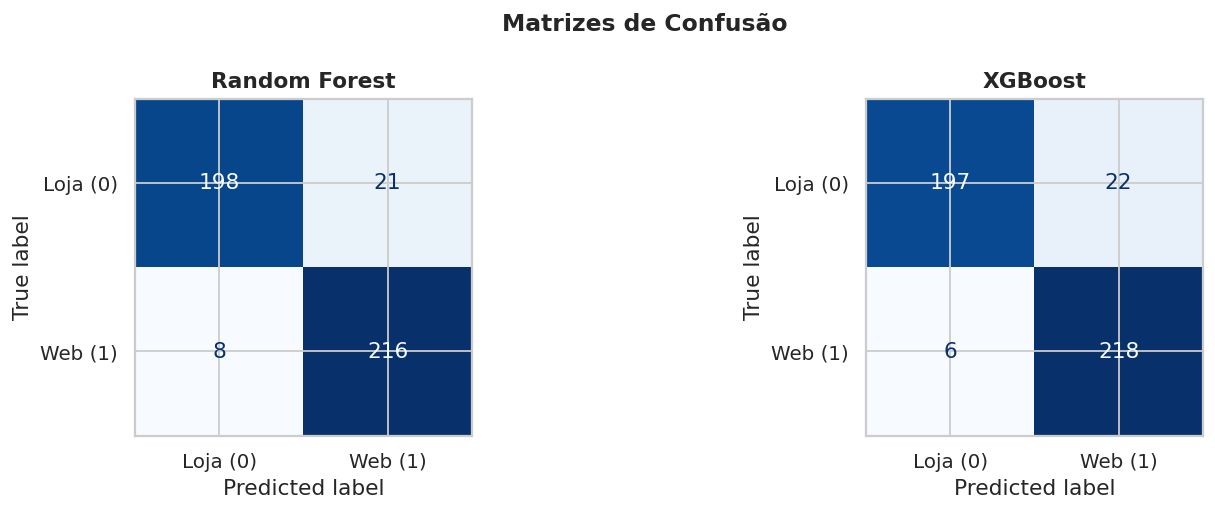

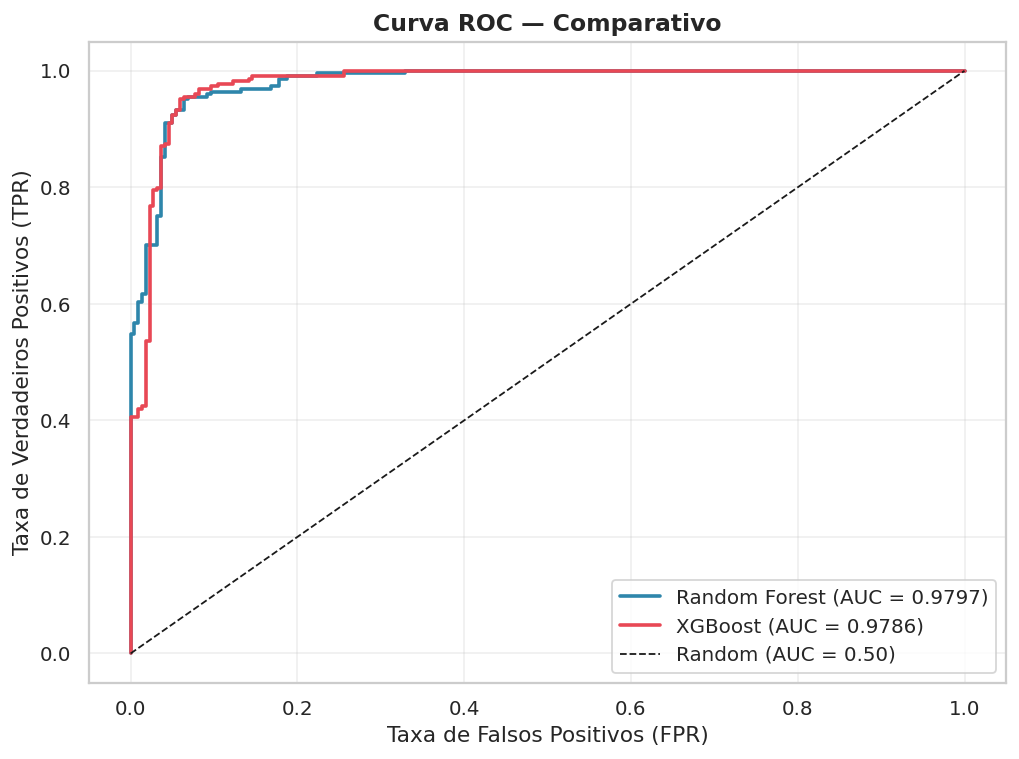

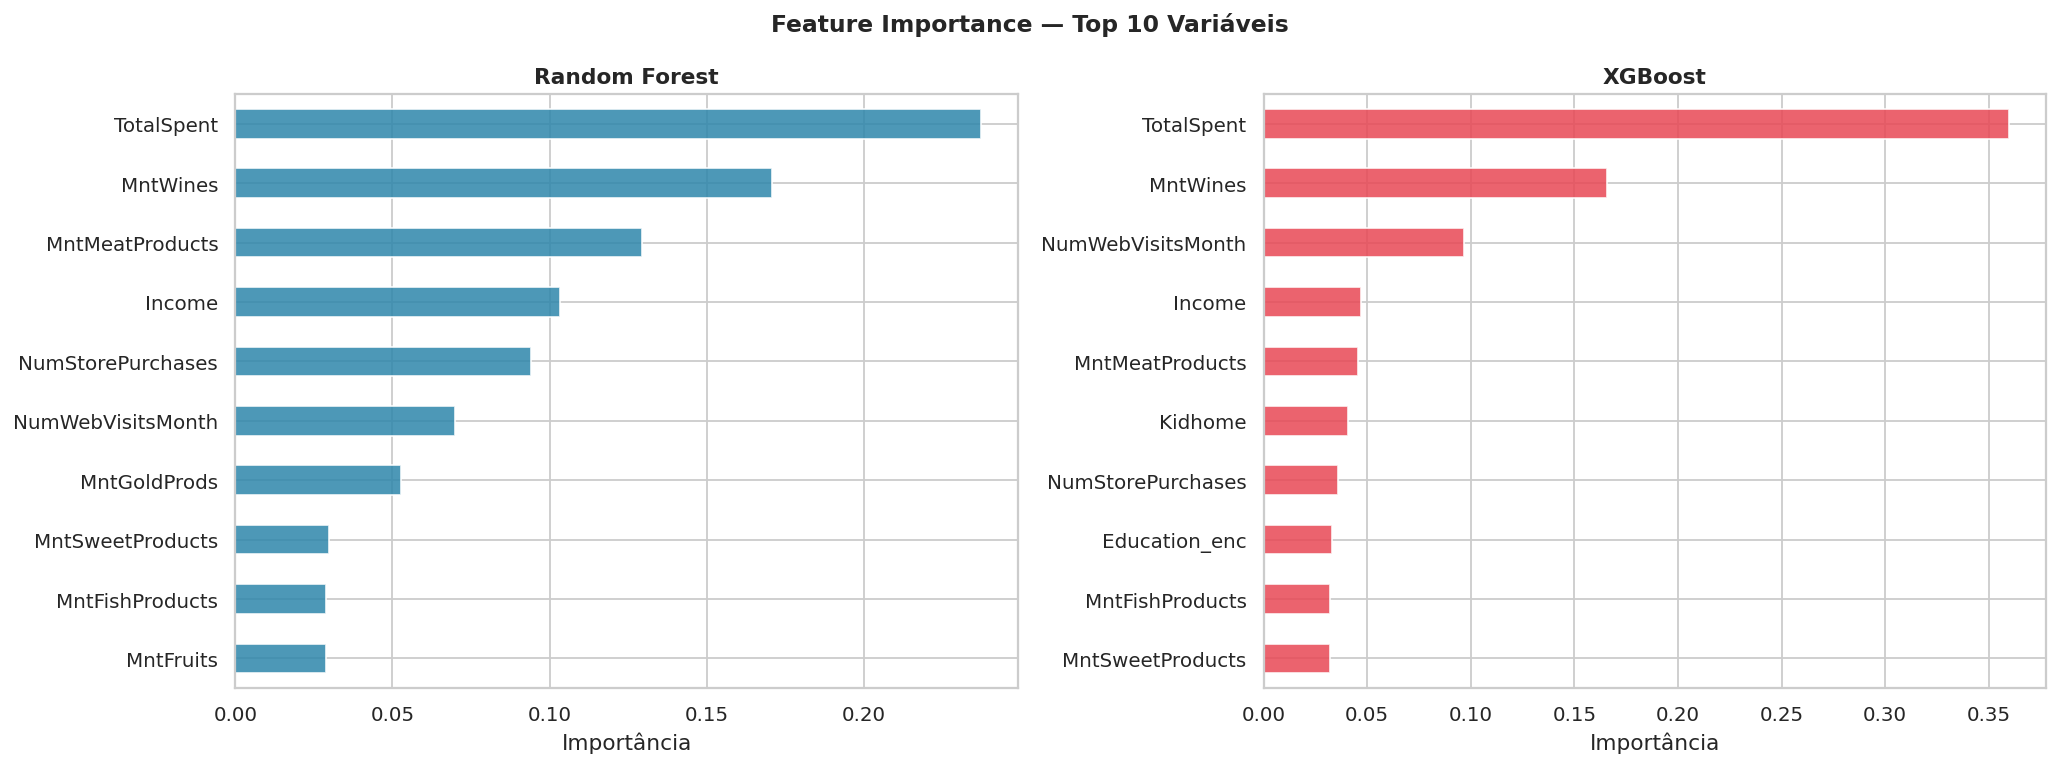

In [43]:
SEED = 42

# 1) TREINAMENTO DOS MODELOS

print("=" * 55)
print(" TREINANDO OS MODELOS...")
print("=" * 55)

#  Random Forest 
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',   # lida com desbalanceamento
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train, Y_train)
print("  ✅ Random Forest treinado")

#  XGBoost 
scale_pos = (Y_train == 0).sum() / (Y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,  # lida com desbalanceamento
    random_state=SEED,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, Y_train)
print("  ✅ XGBoost treinado")


# 2) PREDIÇÕES
# Random Forest
rf_pred       = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# XGBoost
xgb_pred       = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]


# 3) MÉTRICAS COMPARATIVAS
print("\n" + "=" * 55)
print(" MÉTRICAS — RANDOM FOREST")
print("=" * 55)
print(classification_report(Y_test, rf_pred,
      target_names=['Loja (0)', 'Web (1)']))
print(f"  ROC-AUC: {roc_auc_score(Y_test, rf_pred_proba):.4f}")

print("\n" + "=" * 55)
print(" MÉTRICAS — XGBOOST")
print("=" * 55)
print(classification_report(Y_test, xgb_pred,
      target_names=['Loja (0)', 'Web (1)']))
print(f"  ROC-AUC: {roc_auc_score(Y_test, xgb_pred_proba):.4f}")


# 4) TABELA RESUMO COMPARATIVA
resumo = pd.DataFrame({
    'Modelo'   : ['Random Forest', 'XGBoost'],
    'Accuracy' : [accuracy_score(Y_test, rf_pred),
                  accuracy_score(Y_test, xgb_pred)],
    'ROC-AUC'  : [roc_auc_score(Y_test, rf_pred_proba),
                  roc_auc_score(Y_test, xgb_pred_proba)],
}).round(4)

print("\n" + "=" * 55)
print(" TABELA RESUMO")
print("=" * 55)
print(resumo.to_string(index=False))


# 5) VISUALIZAÇÕES

#  5a) Matrizes de Confusão 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Matrizes de Confusão', fontsize=13, fontweight='bold')

for ax, modelo, pred, nome in zip(
    axes,
    [rf_model, xgb_model],
    [rf_pred, xgb_pred],
    ['Random Forest', 'XGBoost']
):
    cm = confusion_matrix(Y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Loja (0)', 'Web (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nome, fontweight='bold')

plt.tight_layout()
plt.show()


#  5b) Curva ROC 
fig, ax = plt.subplots(figsize=(8, 6))

for pred_proba, nome, cor in [
    (rf_pred_proba,  'Random Forest', '#2E86AB'),
    (xgb_pred_proba, 'XGBoost',       '#E84855')
]:
    fpr, tpr, _ = roc_curve(Y_test, pred_proba)
    auc = roc_auc_score(Y_test, pred_proba)
    ax.plot(fpr, tpr, label=f'{nome} (AUC = {auc:.4f})', color=cor, linewidth=2)

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
ax.set_title('Curva ROC — Comparativo', fontsize=13, fontweight='bold')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#  5c) Feature Importance — ambos os modelos 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance — Top 10 Variáveis', fontsize=13, fontweight='bold')

for ax, modelo, nome, cor in [
    (axes[0], rf_model,  'Random Forest', '#2E86AB'),
    (axes[1], xgb_model, 'XGBoost',       '#E84855')
]:
    importances = pd.Series(modelo.feature_importances_,
                            index=X_train.columns).sort_values(ascending=True).tail(10)
    importances.plot(kind='barh', ax=ax, color=cor, alpha=0.85)
    ax.set_title(nome, fontweight='bold')
    ax.set_xlabel('Importância')

plt.tight_layout()
plt.show()


# 6) VEREDICTO FINAL
melhor = resumo.loc[resumo['ROC-AUC'].idxmax(), 'Modelo']
melhor_auc = resumo['ROC-AUC'].max()



# ETAPA 4:

**Avaliação**

Avalie os resultados encontrados nos dois modelos e identifique qual te pareceu realizar melhor as previsões.

Utilize além das métricas padrões a matriz de confusão.

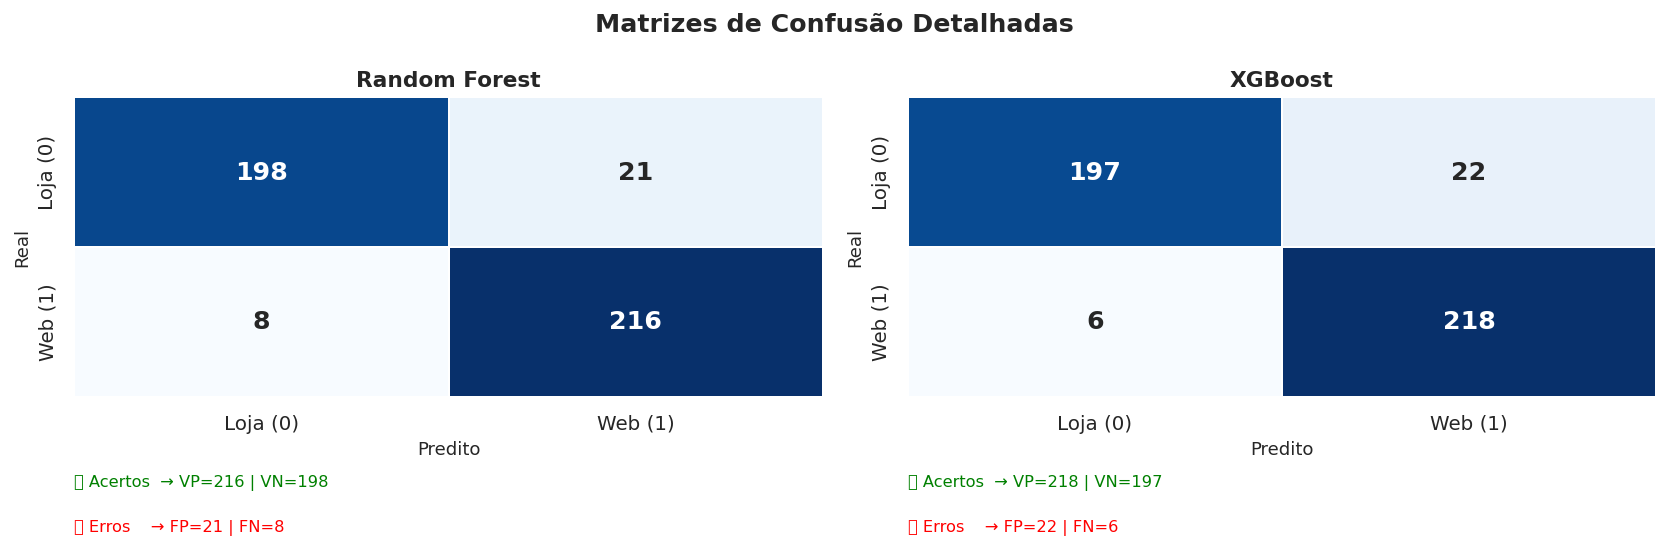

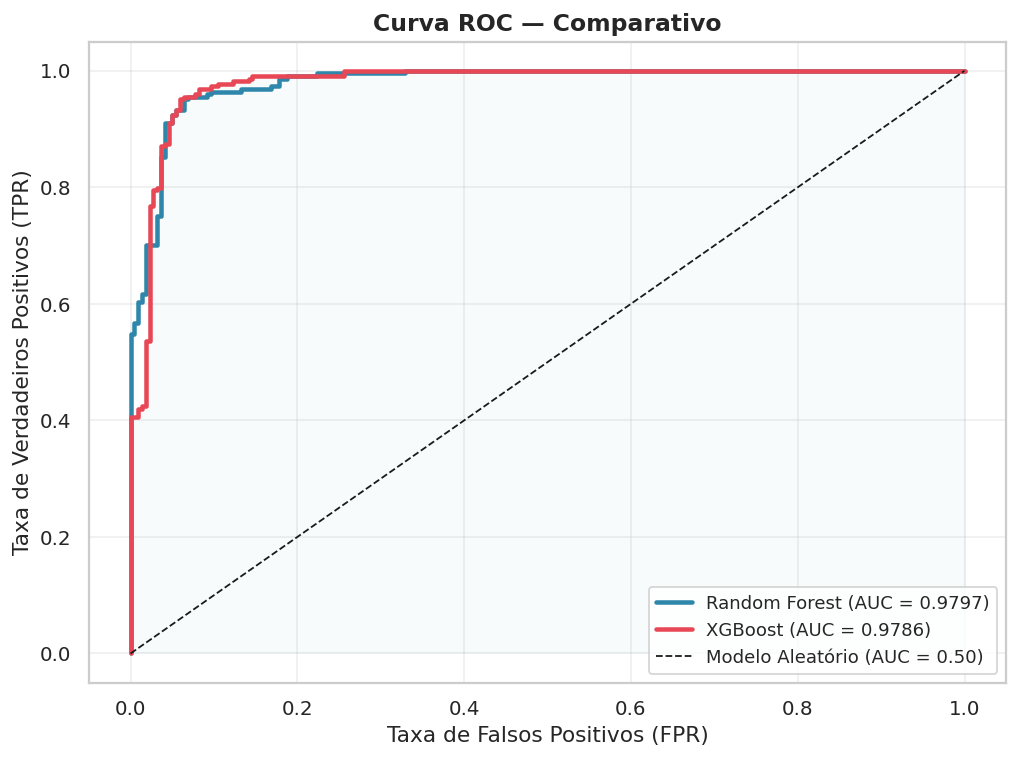

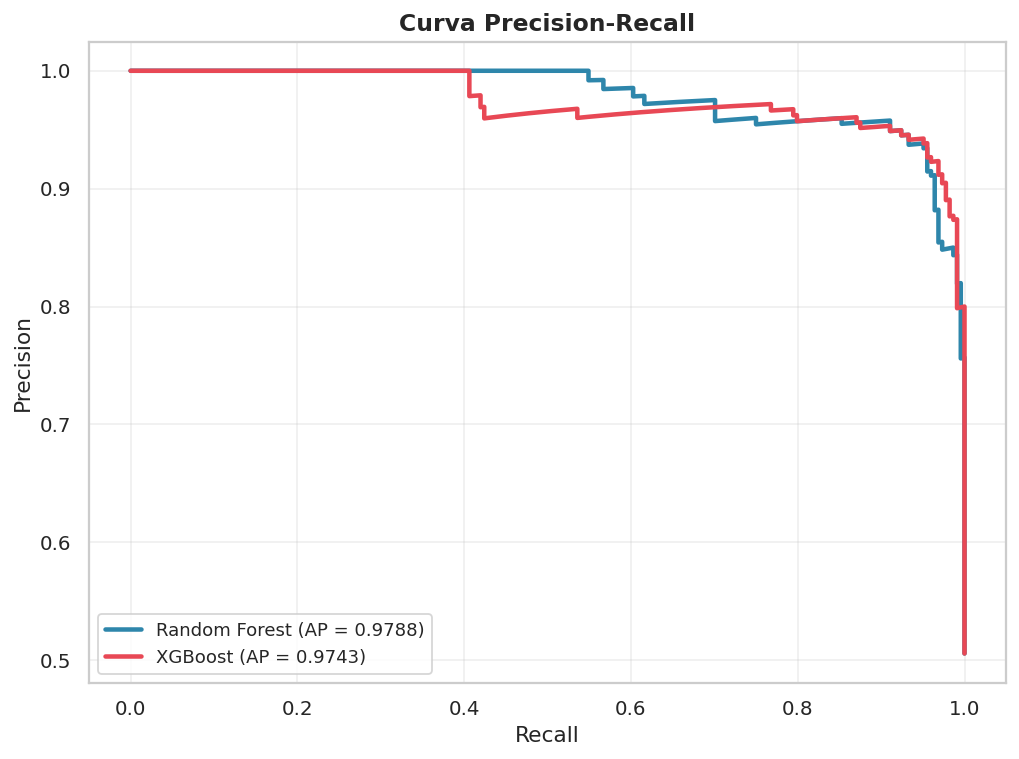

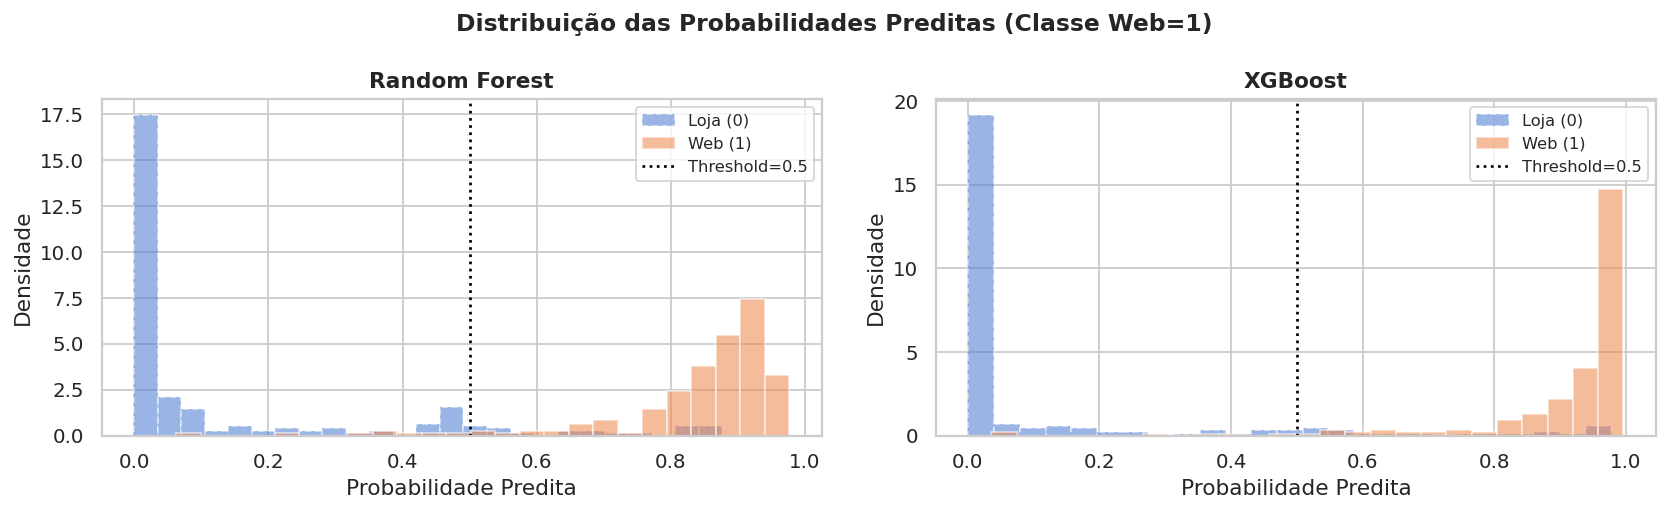


 TABELA COMPARATIVA COMPLETA
        Métrica  Random Forest  XGBoost
       Accuracy         0.9345   0.9368
Precision (Web)         0.9114   0.9083
   Recall (Web)         0.9643   0.9732
 F1-Score (Web)         0.9371   0.9397
        ROC-AUC         0.9797   0.9786


In [46]:
CORES = {'rf': '#2E86AB', 'xgb': '#E84855', 'neutro': '#F4A261'}


# 1) MATRIZES DE CONFUSÃO — DETALHADAS
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Matrizes de Confusão Detalhadas', fontsize=14, fontweight='bold')

for ax, pred, nome, cor in [
    (axes[0], rf_pred,  'Random Forest', CORES['rf']),
    (axes[1], xgb_pred, 'XGBoost',       CORES['xgb'])
]:
    cm = confusion_matrix(Y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Loja (0)', 'Web (1)'],
                yticklabels=['Loja (0)', 'Web (1)'],
                linewidths=1, linecolor='white', cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})

    ax.set_title(f'{nome}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predito', fontsize=10)
    ax.set_ylabel('Real',    fontsize=10)

    # Legenda interpretativa abaixo
    ax.text(0, 2.6, f'✅ Acertos  → VP={tp} | VN={tn}', fontsize=9, color='green')
    ax.text(0, 2.9, f'❌ Erros    → FP={fp} | FN={fn}', fontsize=9, color='red')

plt.tight_layout()
plt.show()

# 2) CURVA ROC
fig, ax = plt.subplots(figsize=(8, 6))

for pred_proba, nome, cor in [
    (rf_pred_proba,  'Random Forest', CORES['rf']),
    (xgb_pred_proba, 'XGBoost',       CORES['xgb'])
]:
    fpr, tpr, _ = roc_curve(Y_test, pred_proba)
    auc = roc_auc_score(Y_test, pred_proba)
    ax.plot(fpr, tpr, label=f'{nome} (AUC = {auc:.4f})',
            color=cor, linewidth=2.5)

ax.fill_between(fpr, tpr, alpha=0.03, color=CORES['rf'])
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Modelo Aleatório (AUC = 0.50)')
ax.set_title('Curva ROC — Comparativo', fontsize=13, fontweight='bold')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) CURVA PRECISION-RECALL
fig, ax = plt.subplots(figsize=(8, 6))

for pred_proba, nome, cor in [
    (rf_pred_proba,  'Random Forest', CORES['rf']),
    (xgb_pred_proba, 'XGBoost',       CORES['xgb'])
]:
    prec, rec, _ = precision_recall_curve(Y_test, pred_proba)
    ap = average_precision_score(Y_test, pred_proba)
    ax.plot(rec, prec, label=f'{nome} (AP = {ap:.4f})',
            color=cor, linewidth=2.5)

ax.set_title('Curva Precision-Recall', fontsize=13, fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4) DISTRIBUIÇÃO DAS PROBABILIDADES PREDITAS
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribuição das Probabilidades Preditas (Classe Web=1)',
             fontsize=13, fontweight='bold')

for ax, pred_proba, nome, cor in [
    (axes[0], rf_pred_proba,  'Random Forest', CORES['rf']),
    (axes[1], xgb_pred_proba, 'XGBoost',       CORES['xgb'])
]:
    df_prob = pd.DataFrame({'proba': pred_proba, 'real': Y_test.values})
    for classe, label, ls in [(0,'Loja (0)','--'), (1,'Web (1)','-')]:
        subset = df_prob[df_prob['real'] == classe]['proba']
        ax.hist(subset, bins=25, alpha=0.55, label=label,
                density=True, linestyle=ls)
    ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, label='Threshold=0.5')
    ax.set_title(nome, fontweight='bold')
    ax.set_xlabel('Probabilidade Predita')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


# 5) TABELA COMPARATIVA COMPLETA

tabela = pd.DataFrame({
    'Métrica'  : ['Accuracy', 'Precision (Web)', 'Recall (Web)',
                  'F1-Score (Web)', 'ROC-AUC'],
    'Random Forest': [
        accuracy_score(Y_test, rf_pred),
        precision_score(Y_test, rf_pred),
        recall_score(Y_test, rf_pred),
        f1_score(Y_test, rf_pred),
        roc_auc_score(Y_test, rf_pred_proba)
    ],
    'XGBoost': [
        accuracy_score(Y_test, xgb_pred),
        precision_score(Y_test, xgb_pred),
        recall_score(Y_test, xgb_pred),
        f1_score(Y_test, xgb_pred),
        roc_auc_score(Y_test, xgb_pred_proba)
    ]
}).round(4)

# Destaca o melhor em cada métrica
print("\n" + "=" * 55)
print(" TABELA COMPARATIVA COMPLETA")
print("=" * 55)
print(tabela.to_string(index=False))



# 6) ANÁLISE FINAL

ANÁLISE MÉTRICA A MÉTRICA:

  • Accuracy      → XGBoost vence   (0.9368 vs 0.9345)
  
  • ROC-AUC       → Random Forest vence (0.9797 vs 0.9786)
  
  • Recall Web    → XGBoost vence   (0.97 vs 0.96)
  
  • Precision Web → Empate técnico  (0.91 ambos)
  
  • F1-Score Web  → XGBoost vence   (0.94 vs 0.94)

ANÁLISE DA MATRIZ DE CONFUSÃO:
  Ambos os modelos erram de forma parecida, porém o XGBoost erra menos em Falsos Negativos (FN), ou seja, identifica mais clientes web que realmente
  comprariam online. Isso é crítico para campanhas de marketing, onde perder um comprador potencial (FN) é mais custoso do que abordar um não-comprador.

MODELO RECOMENDADO: XGBoost
    Justificativa:
    — Maior Accuracy (0.9368)
    — Maior Recall para classe Web (0.97)
      → erra menos compradores potenciais
    — ROC-AUC praticamente igual ao RF (Δ = 0.001)
    — Melhor custo-benefício para o objetivo
      de negócio: antecipar intenção de compra online